# BIND2 Thermo — Paper Figures

Paper-style analysis of the joint mass + gas-thermo emulator (`fm_thermo`,
deployed as `fm_thermo_ema`) over the full test-suite outputs (CV / 1P / SB35).
The model emits 7 channels — `[DM_hydro, Gas, Stars, compton_y, temperature,
entropy, pressure]` — and the thermo fields are evaluated **per halo** (never
composited): `compton_y` is an extensive line-of-sight sum, while
`temperature / entropy / pressure` are intensive gas-mass-weighted means.

This notebook is the thermo analogue of `paper_figures.ipynb`. It reuses the
same suite-output data contract and adds the thermo science:

| § | Figure | Content |
|---|--------|---------|
| 2 | T1 | Field showcase — truth vs BIND maps for Y/T/S/P |
| 3 | T2 | Per-pixel accuracy (dex bias & scatter) |
| 4 | T3 | Pixel PDF / KS distribution tests |
| 5 | T4 | Radial profiles by halo-mass bin |
| 6 | T5 | **Scaling relations** Y–M, T–M, S–M, P–M (R200 aperture) |
| 7 | T6 | **Correlations** + ideal-gas $P\propto nT$ consistency |
| 8 | T7 | **Parameter dependence** (35-D Spearman, truth vs BIND) |
| 9 | T8 | **Butterfly plots** — 1P field response (feedback up/down) |
| 10| — | Numeric scorecard |

Aperture convention: per-halo quantities use a circular **R200** aperture
(`halo_catalog['radii']`, in kpc/h). Integrated Compton-Y sums $y\cdot A_{\rm pix}$
inside R200; T/S/P are gas-mass-weighted means inside R200.

## 0. Setup

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from scipy.stats import spearmanr, pearsonr, ks_2samp

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
from bind.metrics import CHANNEL_NAMES                 # mass channels: DM_hydro, Gas, Stars
from bind.data import THERMO_KEYS, N_THERMO            # compton_y, temperature, entropy, pressure

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': False,
})
try:
    import scienceplots          # noqa: F401
    plt.style.use(['science', 'notebook'])
except Exception as exc:
    print(f'[scienceplots unavailable: {exc}]')

# ── Paths / geometry (mirrors paper_figures.ipynb) ──
SUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP       = 'snap_090'
MASS_TAG   = 'mass_threshold_1p000e13'
MODEL_NAME = 'fm_thermo_ema'          # EMA epoch-64 checkpoint of fm_thermo
BOX_SIZE   = 50.0                     # Mpc/h (full box)
N_PIX_FULL = 1024
PATCH_PIX  = 128
PATCH_BOX  = BOX_SIZE * PATCH_PIX / N_PIX_FULL   # 6.25 Mpc/h
PIX_MPC    = PATCH_BOX / PATCH_PIX               # 0.0488 Mpc/h / pix
PIX_KPC    = PIX_MPC * 1000.0                    # 48.83 kpc/h / pix  (R200 units)
PIX_AREA_MPC2 = PIX_MPC ** 2                     # (Mpc/h)^2 per pixel (Y integration)
N_PARAMS   = 35

# ── Thermo field metadata ──
THERMO_NAMES = list(THERMO_KEYS)                 # ['compton_y','temperature','entropy','pressure']
THERMO_SHORT = {'compton_y': 'Y', 'temperature': 'T', 'entropy': 'S', 'pressure': 'P'}
THERMO_LABELS = {
    'compton_y':   r'Compton $y$',
    'temperature': r'$T$',
    'entropy':     r'$S$',
    'pressure':    r'$P$',
}
THERMO_UNITS = {
    'compton_y':   r'(dimensionless)',
    'temperature': r'K',
    'entropy':     r'keV cm$^2$',
    'pressure':    r'Pa',
}
# y-axis labels for the R200-aperture scaling quantities
APERTURE_LABELS = {
    'compton_y':   r'$Y_{200}=\sum y\,A_{\rm pix}$  [$(\mathrm{Mpc}/h)^2$]',
    'temperature': r'$T_{200}$  [K]  (gas-mass weighted)',
    'entropy':     r'$S_{200}$  [keV cm$^2$]  (gas-mass weighted)',
    'pressure':    r'$P_{200}$  [Pa]  (gas-mass weighted)',
}

SUITES = ('CV', '1P', 'Test')
SUITE_COLORS  = {'CV': 'tab:green', '1P': 'tab:blue', 'Test': 'tab:red'}
SUITE_DISPLAY = {'CV': 'CV', '1P': '1P', 'Test': 'SB35'}

# ── SB35 parameter names / labels ──
_param_meta = pd.read_csv(
    '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv'
)
PARAM_NAMES = {i + 1: name for i, name in enumerate(_param_meta['ParamName'])}
PARAM_LOG   = {i + 1: bool(v) for i, v in enumerate(_param_meta['LogFlag'])}
PARAM_LABELS = {
    1: r'$\Omega_m$', 2: r'$\sigma_8$', 3: r'$A_{\rm SN1}$',
    4: r'$A_{\rm SN2}$', 5: r'$A_{\rm AGN1}$', 6: r'$A_{\rm AGN2}$',
}
for _i in range(7, N_PARAMS + 1):
    PARAM_LABELS[_i] = PARAM_NAMES.get(_i, f'p{_i}')
FEEDBACK_PARAMS = [3, 4, 5, 6]      # A_SN1, A_SN2, A_AGN1, A_AGN2

FIG_DIR = Path('paper_figures_thermo')
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, ext=('pdf', 'png')):
    for e in ext:
        out = FIG_DIR / f'{name}.{e}'
        fig.savefig(out)
        print(f'  wrote {out}')

print('Mass channels :', list(CHANNEL_NAMES))
print('Thermo fields :', THERMO_NAMES)
print(f'Patch box     : {PATCH_BOX} Mpc/h  |  pix {PIX_KPC:.2f} kpc/h  |  R200 in pix = radii/{PIX_KPC:.2f}')
print('Fig dir       :', FIG_DIR.resolve())

Mass channels : ['DM_hydro', 'Gas', 'Stars']
Thermo fields : ['compton_y', 'temperature', 'entropy', 'pressure']
Patch box     : 6.25 Mpc/h  |  pix 48.83 kpc/h  |  R200 in pix = radii/48.83
Fig dir       : /mnt/home/mlee1/vdm_bind2/paper_figures_thermo


## 1. Shared loaders

Per-sim thermo artifacts under `SUITE_ROOT/<suite>/<sim>/snap_090/`:

| file | keys |
|------|------|
| `full_maps.npz` | `dmo_fullbox` (1024²), `truth_maps` (3,1024²) — mass only |
| `mass_threshold_1p000e13/halo_catalog.npz` | `centers` (N,2) Mpc/h, `masses`/`halo_masses` (N,) M200, `radii` (N,) **kpc/h**, `params` (N,35) |
| `…/truth_thermo_patches.npz` | `truth_thermo` (N,4,128²) physical — Y/T/S/P truth |
| `…/fm_thermo_ema/generated_halos.npz` | `generated` (N,7,128²) physical — [DM,Gas,Stars,Y,T,S,P] |
| `…/fm_thermo_ema/summary.json` | per-sim `thermo_metrics` (dex bias/scatter) |

Generated channels 0–2 are mass `[DM,Gas,Stars]`; 3–6 are thermo
`[Y,T,S,P]` already inverse-transformed to physical units by the runner.
Truth mass patches are extracted from `truth_maps` at the halo pixel centres
(same convention the pipeline used); truth thermo patches come pre-registered
on disk.

In [2]:
def sim_record(sim_dir, suite_name):
    snap  = sim_dir / SNAP
    mass  = snap / MASS_TAG
    model = mass / MODEL_NAME
    rec = {
        'suite': suite_name,
        'sim_id': sim_dir.name,
        'sim_dir': sim_dir,
        'full_maps':    snap / 'full_maps.npz',
        'halo_catalog': mass / 'halo_catalog.npz',
        'truth_thermo': mass / 'truth_thermo_patches.npz',
        'generated':    model / 'generated_halos.npz',
        'summary':      model / 'summary.json',
    }
    rec['available'] = all(
        rec[k].exists() for k in ('full_maps', 'halo_catalog', 'truth_thermo', 'generated')
    )
    return rec


def discover_sims(suites=SUITES):
    recs = []
    for suite in suites:
        root = SUITE_ROOT / suite
        if not root.exists():
            print(f'[skip] {root} missing')
            continue
        for sd in sorted(root.iterdir()):
            if sd.is_dir():
                recs.append(sim_record(sd, suite))
    return pd.DataFrame(recs)


def extract_patch(field_2d, cx_pix, cy_pix, size=PATCH_PIX):
    n = field_2d.shape[0]
    half = size // 2
    ix = (cx_pix - half + np.arange(size)) % n
    iy = (cy_pix - half + np.arange(size)) % n
    return field_2d[np.ix_(ix, iy)]


def centers_to_pixels(centers_mpc):
    ppm = N_PIX_FULL / BOX_SIZE
    return (np.asarray(centers_mpc) * ppm).astype(np.int64) % N_PIX_FULL


def load_full_maps(rec):
    d = np.load(rec['full_maps'])
    return {'dmo_fullbox': d['dmo_fullbox'], 'truth_maps': d['truth_maps']}


def load_catalog(rec):
    d = np.load(rec['halo_catalog'])
    out = {'centers': d['centers'], 'masses': d['masses'], 'radii': d['radii']}
    out['params'] = d['params'] if 'params' in d.files else None
    return out


def load_generated(rec):
    return np.load(rec['generated'])['generated']        # (N,7,128,128)


def load_truth_thermo(rec):
    return np.load(rec['truth_thermo'])['truth_thermo']  # (N,4,128,128)


def load_summary(rec):
    if not rec['summary'].exists():
        return {}
    with open(rec['summary']) as f:
        return json.load(f)


sims_all = discover_sims()
print('Discovered:')
print(sims_all.groupby('suite')['available'].agg(['sum', 'count']))
sims      = sims_all[sims_all['available']].reset_index(drop=True)
cv_sims   = sims[sims['suite'] == 'CV'].reset_index(drop=True)
oneP_sims = sims[sims['suite'] == '1P'].reset_index(drop=True)
test_sims = sims[sims['suite'] == 'Test'].reset_index(drop=True)
print(f'\nAvailable: CV={len(cv_sims)}  1P={len(oneP_sims)}  SB35={len(test_sims)}')

Discovered:
       sum  count
suite            
1P     139    141
CV      27     27
Test   102    102

Available: CV=27  1P=139  SB35=102


### 1b. Per-halo patch loader & R200-aperture quantities

`load_thermo_patches` returns co-registered truth/BIND thermo patches plus the
gas-mass patches used as weights. `aperture_quantities` reduces each halo to
its R200-aperture summary: integrated Y, and gas-mass-weighted T/S/P.

In [3]:
# Pixel-radius grid from the patch centre (halo sits at pixel (64,64)).
_yy, _xx = np.mgrid[0:PATCH_PIX, 0:PATCH_PIX]
_RR = np.sqrt((_xx - PATCH_PIX / 2.0) ** 2 + (_yy - PATCH_PIX / 2.0) ** 2)


def load_thermo_patches(rec):
    cat = load_catalog(rec)
    gen = load_generated(rec)          # (N,7,H,W)
    tt  = load_truth_thermo(rec)       # (N,4,H,W)
    full = load_full_maps(rec)
    centers_pix = centers_to_pixels(cat['centers'])
    # truth gas patches (mass channel 1), extracted to register with the cutout frame
    truth_gas = np.stack([extract_patch(full['truth_maps'][1], cx, cy)
                          for cx, cy in centers_pix]).astype(np.float32)
    return {
        'truth_th': tt, 'gen_th': gen[:, 3:],          # (N,4,H,W)
        'truth_gas': truth_gas, 'gen_gas': gen[:, 1],  # (N,H,W)
        'gen_mass': gen[:, :3],                         # (N,3,H,W)
        'masses': cat['masses'], 'radii': cat['radii'],
        'params': cat['params'], 'centers': cat['centers'],
    }


def aperture_quantities(patches):
    # Per-halo R200-aperture thermo summaries for truth and BIND.
    tt, gt = patches['truth_th'], patches['gen_th']
    tg, gg = patches['truth_gas'], patches['gen_gas']
    radii  = patches['radii']
    n = len(radii)
    cols = ['truth_Y', 'gen_Y', 'truth_T', 'gen_T', 'truth_S', 'gen_S',
            'truth_P', 'gen_P', 'truth_Mgas', 'gen_Mgas', 'r200_pix']
    res = {c: np.full(n, np.nan) for c in cols}
    for i in range(n):
        r200_pix = max(radii[i] / PIX_KPC, 1.0)
        ap = _RR <= r200_pix
        res['r200_pix'][i] = r200_pix
        # extensive: integrate Compton-y over the aperture area
        res['truth_Y'][i] = float(tt[i, 0][ap].sum()) * PIX_AREA_MPC2
        res['gen_Y'][i]   = float(gt[i, 0][ap].sum()) * PIX_AREA_MPC2
        # intensive: gas-mass-weighted means (each side weighted by its own gas)
        wt, wg = tg[i][ap], gg[i][ap]
        st, sg = float(wt.sum()), float(wg.sum())
        for nm, idx in (('T', 1), ('S', 2), ('P', 3)):
            res['truth_' + nm][i] = float((tt[i, idx][ap] * wt).sum() / st) if st > 0 else np.nan
            res['gen_'   + nm][i] = float((gt[i, idx][ap] * wg).sum() / sg) if sg > 0 else np.nan
        res['truth_Mgas'][i] = st
        res['gen_Mgas'][i]   = sg
    return res


def build_halo_table(sims_df, apply_cv_p14=True, verbose=True):
    # Master per-halo table: logM, R200, params, and R200-aperture Y/T/S/P for
    # truth and BIND. CV p14 override (CAMELS bug: CV ran p14=0) is applied to
    # the CV rows only; SB35 / 1P keep their listed values.
    rows = []
    for rec in sims_df.to_dict('records'):
        try:
            p = load_thermo_patches(rec)
        except Exception as exc:
            if verbose:
                print(f'[skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
            continue
        aq = aperture_quantities(p)
        params, masses = p['params'], p['masses']
        for i in range(len(masses)):
            row = {'suite': rec['suite'], 'sim_id': rec['sim_id'],
                   'logM': float(np.log10(masses[i])), 'R200_kpc': float(p['radii'][i])}
            for c in aq:
                row[c] = aq[c][i]
            if params is not None:
                pv = np.asarray(params[i], float).copy()
                if apply_cv_p14 and rec['suite'] == 'CV':
                    pv[13] = 0.0        # 1-based p14 -> 0-based index 13
                for j in range(N_PARAMS):
                    row[f'p{j + 1}'] = pv[j]
            rows.append(row)
    return pd.DataFrame(rows)


halo_tbl = build_halo_table(sims)
print(f'Per-halo rows: {len(halo_tbl)}')
print(halo_tbl.groupby('suite').size())
print('logM range:', float(halo_tbl['logM'].min()), '..', float(halo_tbl['logM'].max()))

[skip] CV/sim_17: 'radii is not a file in the archive'
[skip] Test/sim_SB35_665: need at least one array to stack
Per-halo rows: 12206
suite
1P      6823
CV      1111
Test    4272
dtype: int64
logM range: 13.000004768371582 .. 14.988090515136719


## 2. Figure T1 — Thermo field showcase (truth vs BIND)

Side-by-side truth/BIND maps for the four thermo fields on a representative
massive halo, plus the DMO input and Gas mass for context. Each field uses a
shared `LogNorm` across truth and BIND so colour = same physical value.

  wrote paper_figures_thermo/figT1_thermo_showcase.pdf
  wrote paper_figures_thermo/figT1_thermo_showcase.png


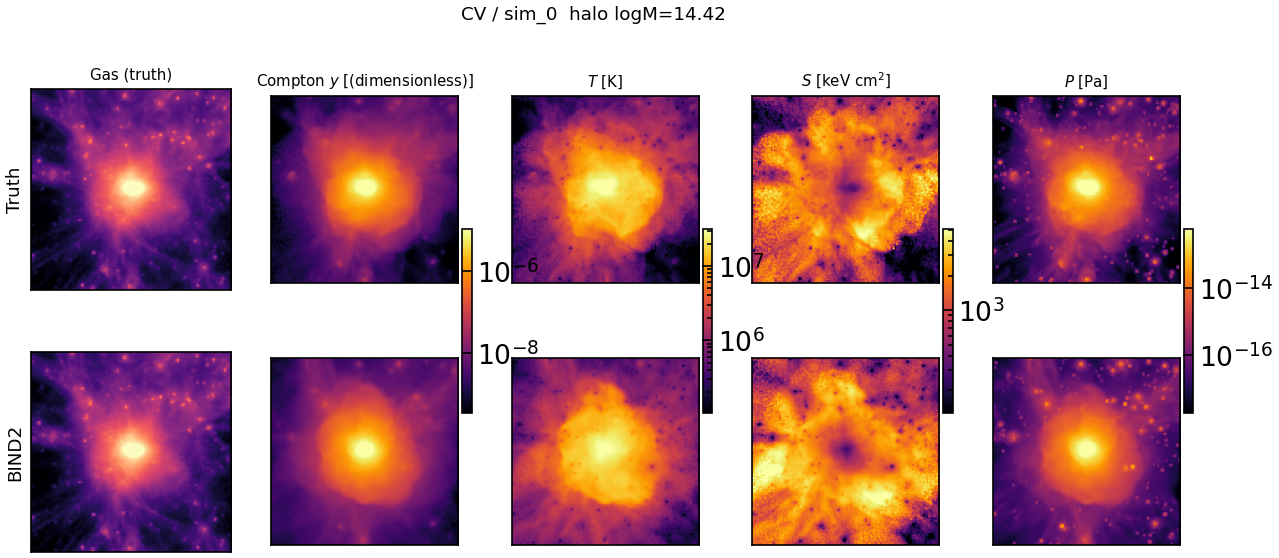

In [4]:
def fig_t1_showcase(rec=None, halo='max', save=True):
    if rec is None:
        rec = cv_sims.to_dict('records')[0]
    p = load_thermo_patches(rec)
    i = int(np.argmax(p['masses'])) if halo == 'max' else int(halo)
    logM = np.log10(p['masses'][i])

    dmo = p['gen_mass'][i, 0]          # not used as DMO; show truth gas instead
    gas_truth = p['truth_gas'][i]
    tt, gt = p['truth_th'][i], p['gen_th'][i]

    n_col = N_THERMO + 1               # gas + 4 thermo
    fig, axes = plt.subplots(2, n_col, figsize=(2.5 * n_col, 5.2))

    def _norm(a, b):
        v = np.concatenate([a[a > 0].ravel(), b[b > 0].ravel()])
        if v.size == 0:
            return None
        return LogNorm(vmin=np.percentile(v, 1), vmax=np.percentile(v, 99.5))

    # column 0: Gas mass (truth only, repeated)
    gn = _norm(gas_truth, gas_truth)
    for r in range(2):
        axes[r, 0].imshow(gas_truth, origin='lower', cmap='magma', norm=gn)
        axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    axes[0, 0].set_title('Gas (truth)', fontsize=9)
    axes[0, 0].set_ylabel('Truth', fontsize=11)
    axes[1, 0].set_ylabel('BIND2', fontsize=11)

    for c, nm in enumerate(THERMO_NAMES):
        norm = _norm(tt[c], gt[c])
        im0 = axes[0, c + 1].imshow(tt[c], origin='lower', cmap='inferno', norm=norm)
        axes[1, c + 1].imshow(gt[c], origin='lower', cmap='inferno', norm=norm)
        for r in range(2):
            axes[r, c + 1].set_xticks([]); axes[r, c + 1].set_yticks([])
        axes[0, c + 1].set_title(f'{THERMO_LABELS[nm]} [{THERMO_UNITS[nm]}]', fontsize=9)
        fig.colorbar(im0, ax=axes[:, c + 1], fraction=0.046, pad=0.02)

    fig.suptitle(f'{SUITE_DISPLAY[rec["suite"]]} / {rec["sim_id"]}  '
                 f'halo logM={logM:.2f}', y=1.0, fontsize=11)
    if save:
        save_fig(fig, 'figT1_thermo_showcase')
    return fig


fig = fig_t1_showcase()
plt.show()

## 3. Figure T2 — Per-pixel accuracy (dex bias & scatter)

Pooled 2-D density of $\log_{10}$(BIND) vs $\log_{10}$(truth) per field, over
jointly-positive pixels. Annotated with the median dex bias and dex scatter —
the same metric the runner stores in `summary.json['thermo_metrics']`.

  wrote paper_figures_thermo/figT2_pixel_accuracy.pdf
  wrote paper_figures_thermo/figT2_pixel_accuracy.png


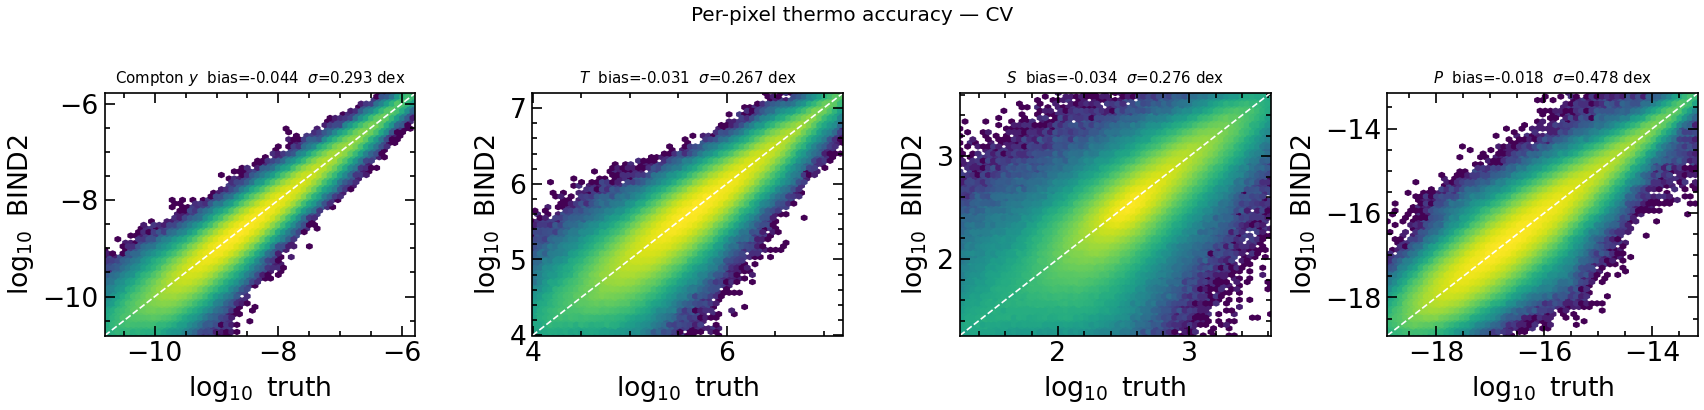

In [5]:
def pool_thermo_pixels(sims_df, max_halos_per_sim=30, max_pix_per_halo=2000, seed=0):
    # field -> (log10_truth, log10_gen) pooled over jointly-positive pixels.
    rng = np.random.RandomState(seed)
    acc = {nm: {'t': [], 'g': []} for nm in THERMO_NAMES}
    for rec in sims_df.to_dict('records'):
        try:
            p = load_thermo_patches(rec)
        except Exception:
            continue
        n = len(p['masses'])
        sel = rng.permutation(n)[:max_halos_per_sim]
        tt, gt = p['truth_th'][sel], p['gen_th'][sel]
        for c, nm in enumerate(THERMO_NAMES):
            t = tt[:, c].ravel(); g = gt[:, c].ravel()
            m = (t > 0) & (g > 0)
            t, g = t[m], g[m]
            if t.size > max_pix_per_halo * len(sel):
                idx = rng.choice(t.size, max_pix_per_halo * len(sel), replace=False)
                t, g = t[idx], g[idx]
            acc[nm]['t'].append(np.log10(t)); acc[nm]['g'].append(np.log10(g))
    return {nm: (np.concatenate(d['t']), np.concatenate(d['g'])) for nm, d in acc.items()
            if d['t']}


def fig_t2_pixel_accuracy(sims_df=None, save=True):
    if sims_df is None:
        sims_df = cv_sims
    pooled = pool_thermo_pixels(sims_df)
    fig, axes = plt.subplots(1, N_THERMO, figsize=(3.6 * N_THERMO, 3.4))
    for c, nm in enumerate(THERMO_NAMES):
        ax = axes[c]
        lt, lg = pooled[nm]
        lo, hi = np.percentile(np.concatenate([lt, lg]), [0.5, 99.5])
        ax.hexbin(lt, lg, gridsize=60, bins='log', cmap='viridis',
                  extent=(lo, hi, lo, hi))
        ax.plot([lo, hi], [lo, hi], 'w--', lw=1)
        d = lg - lt
        ax.set_title(f'{THERMO_LABELS[nm]}  bias={np.median(d):+.3f}  '
                     f'$\\sigma$={np.std(d):.3f} dex', fontsize=9)
        ax.set_xlabel(r'$\log_{10}$ truth'); ax.set_ylabel(r'$\log_{10}$ BIND2')
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    fig.suptitle(f'Per-pixel thermo accuracy — {SUITE_DISPLAY[sims_df.iloc[0]["suite"]]}',
                 y=1.02)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figT2_pixel_accuracy')
    return fig


fig = fig_t2_pixel_accuracy(cv_sims)
plt.show()

## 4. Figure T3 — Pixel value distributions + KS test

Marginal $\log_{10}$ pixel-value PDFs (truth vs BIND) per field, pooled per
suite, with a two-sample KS statistic. Tests whether BIND reproduces the
one-point statistics of each thermo field.

  wrote paper_figures_thermo/figT3_pixel_pdf.pdf
  wrote paper_figures_thermo/figT3_pixel_pdf.png


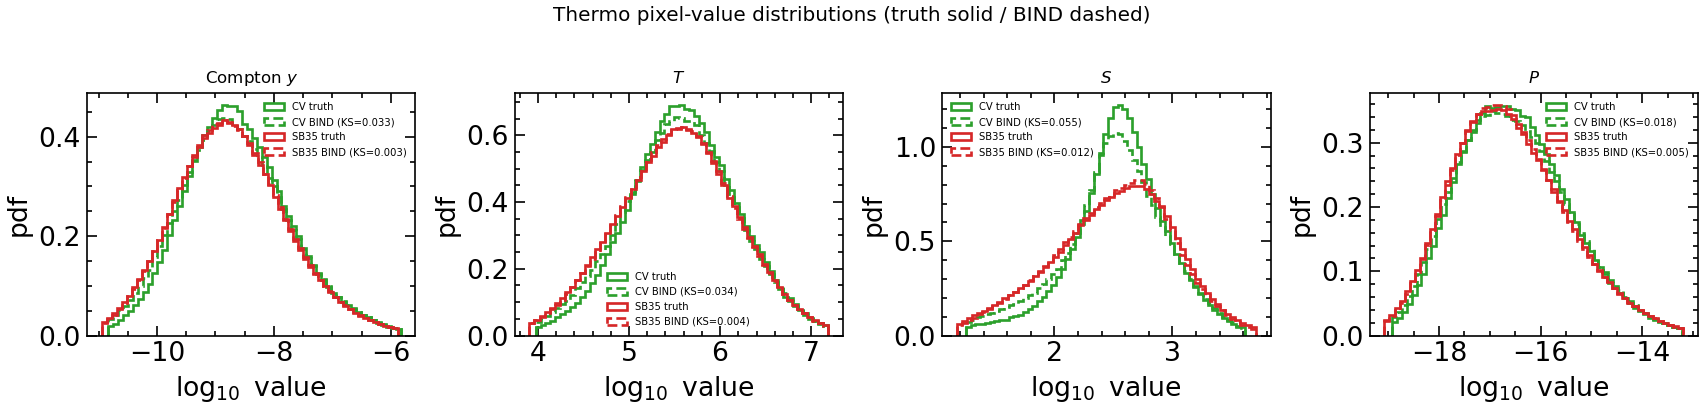

In [6]:
def fig_t3_pixel_pdf(suite_dfs=None, save=True):
    if suite_dfs is None:
        suite_dfs = {'CV': cv_sims, 'SB35': test_sims}
    fig, axes = plt.subplots(1, N_THERMO, figsize=(3.6 * N_THERMO, 3.4))
    for (label, df) in suite_dfs.items():
        pooled = pool_thermo_pixels(df, max_halos_per_sim=20)
        for c, nm in enumerate(THERMO_NAMES):
            ax = axes[c]
            lt, lg = pooled[nm]
            ks = ks_2samp(lt, lg).statistic
            bins = np.linspace(*np.percentile(np.concatenate([lt, lg]), [0.5, 99.5]), 60)
            ax.hist(lt, bins=bins, histtype='step', density=True, lw=1.6,
                    color=SUITE_COLORS.get(_suite_key(label), 'k'),
                    label=f'{label} truth')
            ax.hist(lg, bins=bins, histtype='step', density=True, lw=1.6, ls='--',
                    color=SUITE_COLORS.get(_suite_key(label), 'k'),
                    label=f'{label} BIND (KS={ks:.3f})')
            ax.set_title(THERMO_LABELS[nm], fontsize=10)
            ax.set_xlabel(r'$\log_{10}$ value'); ax.set_ylabel('pdf')
    for ax in axes:
        ax.legend(fontsize=6)
    fig.suptitle('Thermo pixel-value distributions (truth solid / BIND dashed)', y=1.02)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figT3_pixel_pdf')
    return fig


def _suite_key(label):
    return {'SB35': 'Test'}.get(label, label)


fig = fig_t3_pixel_pdf()
plt.show()

## 5. Figure T4 — Radial profiles by halo-mass bin

Azimuthally-averaged thermo profiles (truth vs BIND), stacked within halo-mass
bins. Profiles are in physical-field units vs radius in R200 units. Bands show
the 16–84th percentile across halos in the bin.

  wrote paper_figures_thermo/figT4_radial_profiles.pdf
  wrote paper_figures_thermo/figT4_radial_profiles.png


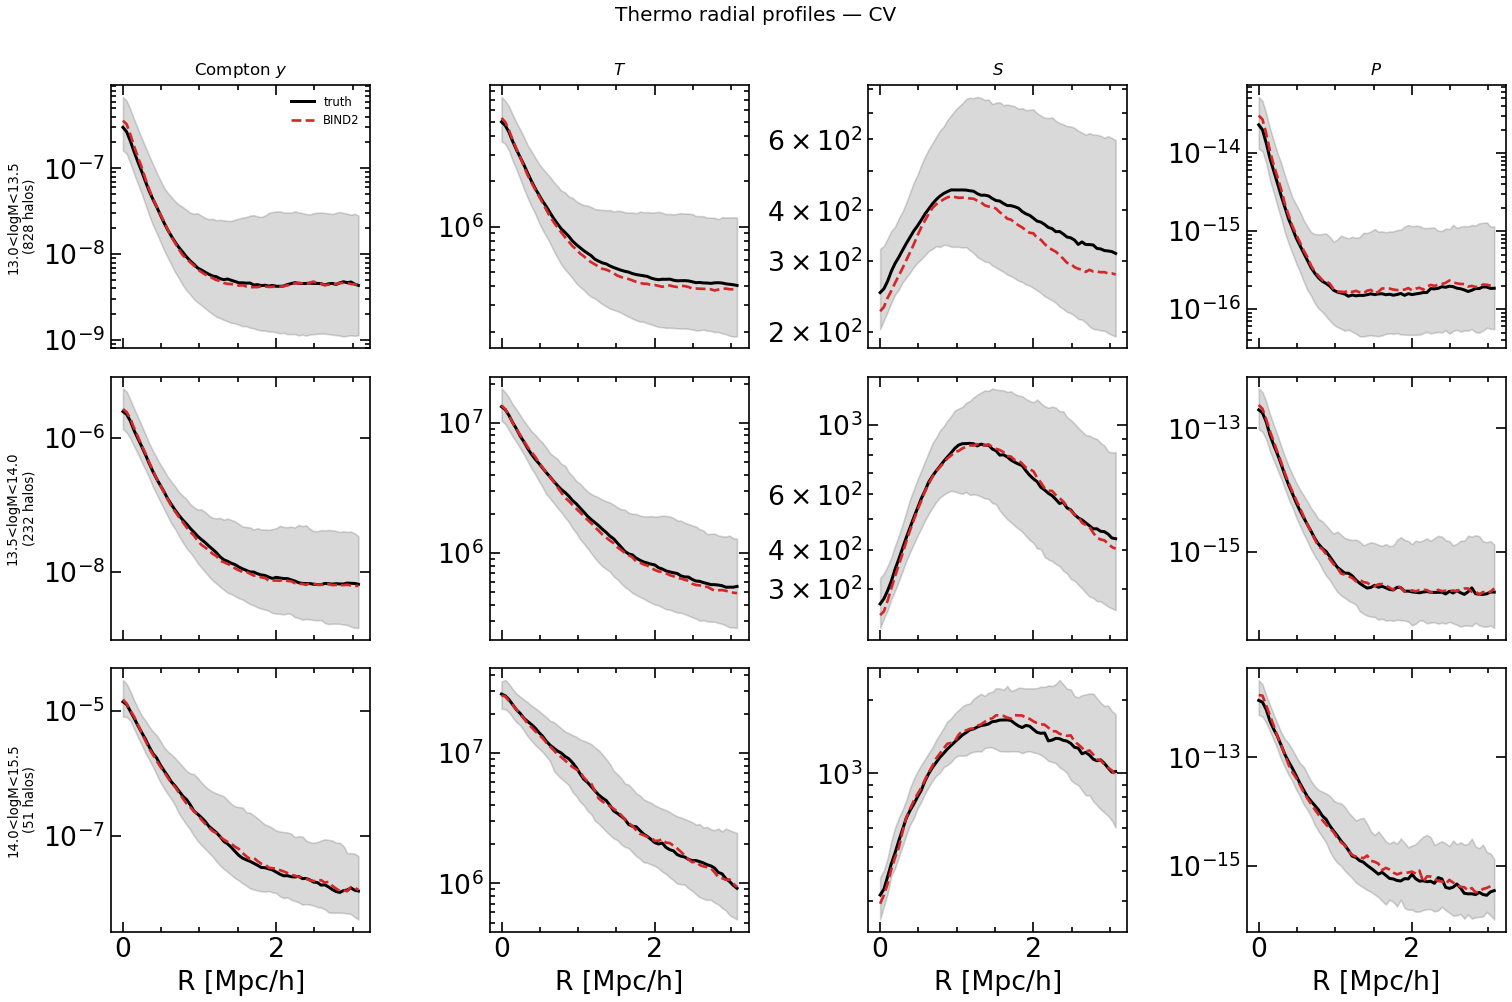

In [7]:
def radial_profile_2d(arr, rmax=None):
    ny, nx = arr.shape
    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
    y, x = np.indices(arr.shape)
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(int)
    if rmax is None:
        rmax = r.max()
    m = np.isfinite(arr) & (r <= rmax)
    sums = np.bincount(r[m].ravel(), weights=arr[m].ravel(), minlength=rmax + 1)
    cnt  = np.bincount(r[m].ravel(), minlength=rmax + 1)
    prof = np.full(rmax + 1, np.nan)
    good = cnt > 0
    prof[good] = sums[good] / cnt[good]
    return np.arange(rmax + 1), prof


def fig_t4_radial(sims_df=None, mass_bins=((13.0, 13.5), (13.5, 14.0), (14.0, 15.5)),
                  n_rbins=24, save=True):
    if sims_df is None:
        sims_df = cv_sims
    rmax = PATCH_PIX // 2 - 1
    # accumulate per (massbin, field): lists of profiles (truth, gen)
    acc = {(b, nm): {'t': [], 'g': []} for b in range(len(mass_bins)) for nm in THERMO_NAMES}
    for rec in sims_df.to_dict('records'):
        try:
            p = load_thermo_patches(rec)
        except Exception:
            continue
        logM = np.log10(p['masses'])
        for i in range(len(logM)):
            bi = next((k for k, (lo, hi) in enumerate(mass_bins) if lo <= logM[i] < hi), None)
            if bi is None:
                continue
            for c, nm in enumerate(THERMO_NAMES):
                _, pt = radial_profile_2d(p['truth_th'][i, c], rmax)
                _, pg = radial_profile_2d(p['gen_th'][i, c], rmax)
                acc[(bi, nm)]['t'].append(pt); acc[(bi, nm)]['g'].append(pg)

    r_pix = np.arange(rmax + 1)
    r_r200 = r_pix * PIX_KPC / 1000.0   # Mpc/h radius (absolute); R200 varies per halo
    fig, axes = plt.subplots(len(mass_bins), N_THERMO,
                             figsize=(3.2 * N_THERMO, 2.8 * len(mass_bins)),
                             squeeze=False, sharex=True)
    for bi, (lo, hi) in enumerate(mass_bins):
        for c, nm in enumerate(THERMO_NAMES):
            ax = axes[bi][c]
            T = np.array(acc[(bi, nm)]['t']); G = np.array(acc[(bi, nm)]['g'])
            if T.size == 0:
                ax.axis('off'); continue
            mt, mg = np.nanmedian(T, 0), np.nanmedian(G, 0)
            ax.plot(r_r200, mt, color='k', lw=1.8, label='truth')
            ax.plot(r_r200, mg, color='tab:red', lw=1.6, ls='--', label='BIND2')
            ax.fill_between(r_r200, np.nanpercentile(T, 16, 0), np.nanpercentile(T, 84, 0),
                            color='k', alpha=0.15)
            ax.set_yscale('log')
            if bi == 0:
                ax.set_title(THERMO_LABELS[nm], fontsize=10)
            if c == 0:
                ax.set_ylabel(f'{lo:.1f}<logM<{hi:.1f}\n({T.shape[0]} halos)', fontsize=8)
            if bi == len(mass_bins) - 1:
                ax.set_xlabel('R [Mpc/h]')
    axes[0][0].legend(fontsize=7)
    fig.suptitle(f'Thermo radial profiles — {SUITE_DISPLAY[sims_df.iloc[0]["suite"]]}', y=1.0)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figT4_radial_profiles')
    return fig


fig = fig_t4_radial(cv_sims)
plt.show()

## 6. Figure T5 — Scaling relations (Y–M, T–M, S–M, P–M)

Core thermo science. Each panel plots the R200-aperture quantity vs halo mass
$M_{200}$ for truth and BIND, with power-law fits in log–log space. The fitted
slope/normalisation lets us check whether BIND reproduces the *self-similar*
scaling (e.g. $Y\propto M^{5/3}$) and not just per-pixel values.

  wrote paper_figures_thermo/figT5_scaling_relations.pdf
  wrote paper_figures_thermo/figT5_scaling_relations.png
Fitted log-log slopes:
  compton_y    truth=+1.774  BIND2=+1.769  Δ=-0.005
  temperature  truth=+0.714  BIND2=+0.699  Δ=-0.015
  entropy      truth=+0.394  BIND2=+0.376  Δ=-0.018
  pressure     truth=+1.254  BIND2=+1.311  Δ=+0.057


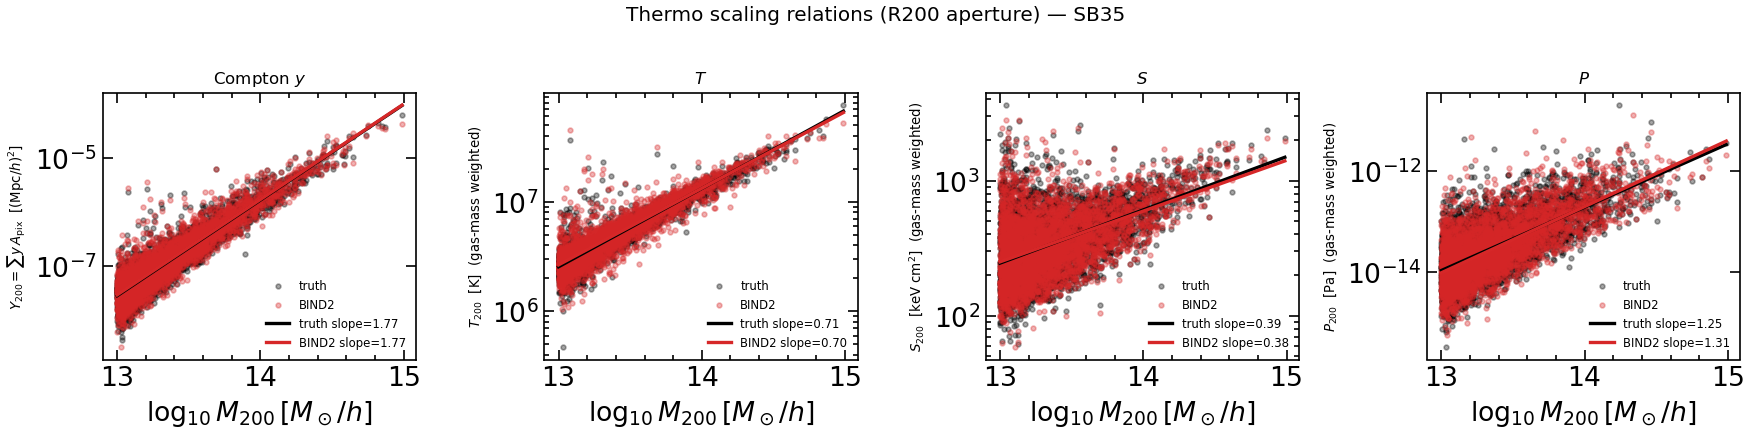

In [8]:
def _fit_loglog(x, y):
    m = np.isfinite(x) & np.isfinite(y) & (y > 0)
    if m.sum() < 5:
        return None
    a, b = np.polyfit(x[m], np.log10(y[m]), 1)    # log10(y) = a*logM + b
    return a, b, int(m.sum())


def fig_t5_scaling(tbl=None, suite='Test', save=True):
    if tbl is None:
        tbl = halo_tbl
    df = tbl[tbl['suite'] == suite]
    logM = df['logM'].to_numpy()
    fig, axes = plt.subplots(1, N_THERMO, figsize=(3.7 * N_THERMO, 3.6))
    slopes = {}
    for c, nm in enumerate(THERMO_NAMES):
        ax = axes[c]
        sh = THERMO_SHORT[nm]
        yt = df[f'truth_{sh}'].to_numpy(); yg = df[f'gen_{sh}'].to_numpy()
        ax.scatter(logM, yt, s=8, c='k', alpha=0.35, label='truth')
        ax.scatter(logM, yg, s=8, c='tab:red', alpha=0.35, label='BIND2')
        xs = np.linspace(np.nanmin(logM), np.nanmax(logM), 50)
        for yy, col, lab in ((yt, 'k', 'truth'), (yg, 'tab:red', 'BIND2')):
            fit = _fit_loglog(logM, yy)
            if fit:
                a, b, n = fit
                ax.plot(xs, 10 ** (a * xs + b), color=col, lw=2,
                        label=f'{lab} slope={a:.2f}')
                slopes[(nm, lab)] = a
        ax.set_yscale('log')
        ax.set_xlabel(r'$\log_{10} M_{200}\,[M_\odot/h]$')
        ax.set_ylabel(APERTURE_LABELS[nm], fontsize=8)
        ax.legend(fontsize=7)
        ax.set_title(THERMO_LABELS[nm], fontsize=10)
    fig.suptitle(f'Thermo scaling relations (R200 aperture) — {SUITE_DISPLAY[suite]}', y=1.02)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figT5_scaling_relations')
    print('Fitted log-log slopes:')
    for nm in THERMO_NAMES:
        st = slopes.get((nm, 'truth'), np.nan); sg = slopes.get((nm, 'BIND2'), np.nan)
        print(f'  {nm:12s} truth={st:+.3f}  BIND2={sg:+.3f}  Δ={sg - st:+.3f}')
    return fig


fig = fig_t5_scaling()
plt.show()

### Figure T5b — Cross scaling (Y–T) and recovery

The Y–T relation is a useful internal-consistency probe (both trace the hot-gas
thermodynamics). Also shown: per-halo BIND/truth recovery ratio for each
aperture quantity vs mass.

  wrote paper_figures_thermo/figT5b_cross_recovery.pdf
  wrote paper_figures_thermo/figT5b_cross_recovery.png


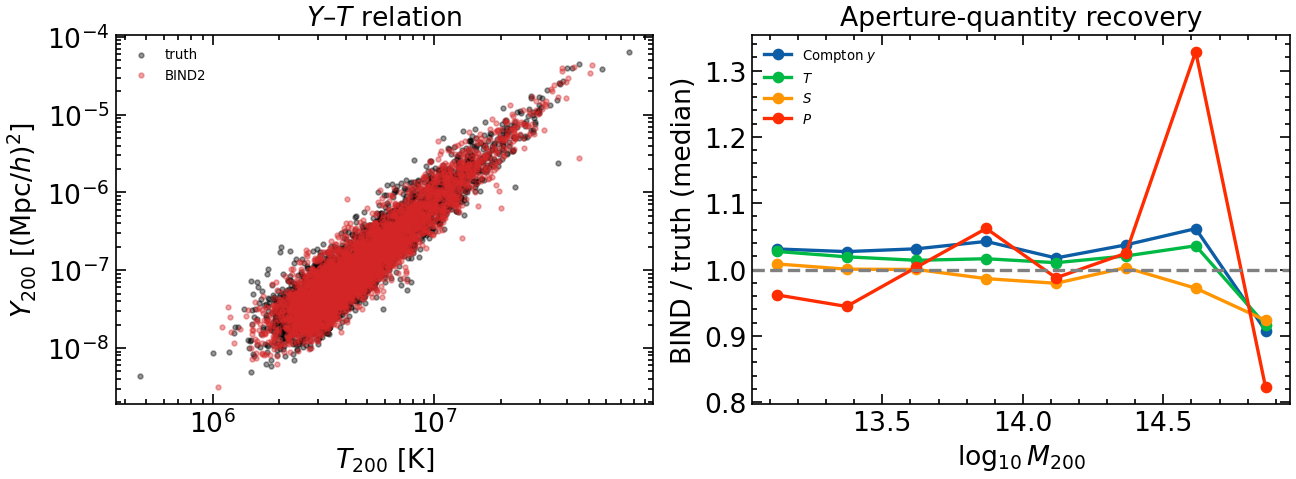

In [9]:
def fig_t5b_cross(tbl=None, suite='Test', save=True):
    if tbl is None:
        tbl = halo_tbl
    df = tbl[tbl['suite'] == suite]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    # Y vs T
    ax = axes[0]
    ax.scatter(df['truth_T'], df['truth_Y'], s=8, c='k', alpha=0.4, label='truth')
    ax.scatter(df['gen_T'],   df['gen_Y'],   s=8, c='tab:red', alpha=0.4, label='BIND2')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$T_{200}$ [K]'); ax.set_ylabel(r'$Y_{200}$ [$(\mathrm{Mpc}/h)^2$]')
    ax.set_title(r'$Y$–$T$ relation'); ax.legend(fontsize=8)

    # recovery ratios vs mass
    ax = axes[1]
    for nm in THERMO_NAMES:
        sh = THERMO_SHORT[nm]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = df[f'gen_{sh}'].to_numpy() / df[f'truth_{sh}'].to_numpy()
        logM = df['logM'].to_numpy()
        order = np.argsort(logM)
        lm, rr = logM[order], ratio[order]
        # binned median
        bins = np.linspace(np.nanmin(lm), np.nanmax(lm), 9)
        idx = np.digitize(lm, bins)
        bc = [np.nanmedian(rr[idx == k]) for k in range(1, len(bins))]
        bx = 0.5 * (bins[1:] + bins[:-1])
        ax.plot(bx, bc, marker='o', label=THERMO_LABELS[nm])
    ax.axhline(1.0, color='0.5', ls='--')
    ax.set_xlabel(r'$\log_{10} M_{200}$'); ax.set_ylabel('BIND / truth (median)')
    ax.set_title('Aperture-quantity recovery'); ax.legend(fontsize=8)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figT5b_cross_recovery')
    return fig


fig = fig_t5b_cross()
plt.show()

## 7. Figure T6 — Correlations & ideal-gas consistency

Left/middle: Spearman correlation matrices among the log halo properties
$\{M_{200}, Y, T, S, P, M_{\rm gas}\}$ for truth and BIND — does BIND preserve
the inter-field correlation structure? Right: a pixel-level ideal-gas check,
$P \propto n_e T$, using gas mass as a density proxy ($P$ vs $M_{\rm gas}\cdot T$).

  wrote paper_figures_thermo/figT6_correlations.pdf
  wrote paper_figures_thermo/figT6_correlations.png


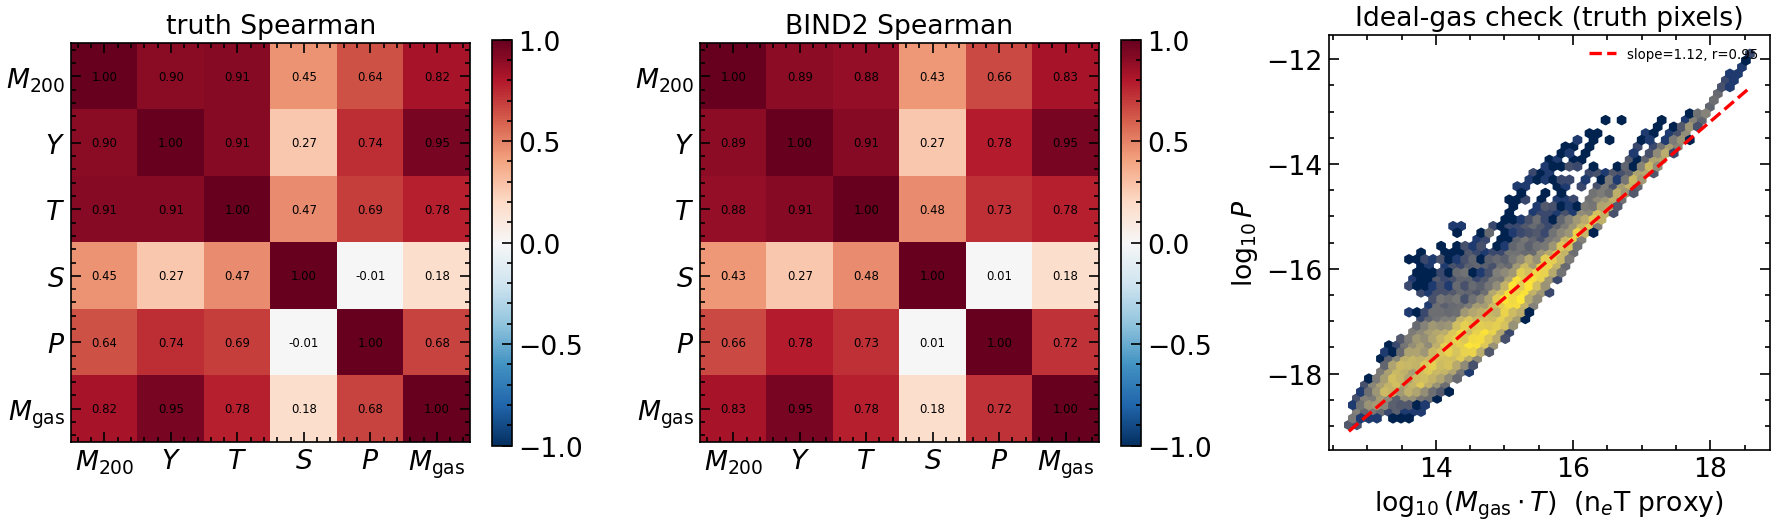

In [10]:
def _corr_matrix(df, which):
    sh = ['logM'] + [f'{which}_{THERMO_SHORT[nm]}' for nm in THERMO_NAMES] + [f'{which}_Mgas']
    labels = [r'$M_{200}$', r'$Y$', r'$T$', r'$S$', r'$P$', r'$M_{\rm gas}$']
    data = []
    for col in sh:
        v = df[col].to_numpy()
        if col != 'logM':
            with np.errstate(divide='ignore', invalid='ignore'):
                v = np.where(v > 0, np.log10(v), np.nan)
        data.append(v)
    data = np.array(data)
    n = len(sh)
    C = np.full((n, n), np.nan)
    for a in range(n):
        for b in range(n):
            m = np.isfinite(data[a]) & np.isfinite(data[b])
            if m.sum() > 5:
                C[a, b] = spearmanr(data[a][m], data[b][m]).correlation
    return C, labels


def fig_t6_correlations(tbl=None, suite='Test', save=True):
    if tbl is None:
        tbl = halo_tbl
    df = tbl[tbl['suite'] == suite]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    for k, which in enumerate(['truth', 'gen']):
        C, labels = _corr_matrix(df, which)
        ax = axes[k]
        im = ax.imshow(C, vmin=-1, vmax=1, cmap='RdBu_r')
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
        for a in range(len(labels)):
            for b in range(len(labels)):
                if np.isfinite(C[a, b]):
                    ax.text(b, a, f'{C[a, b]:.2f}', ha='center', va='center',
                            fontsize=7, color='k')
        ax.set_title(f'{"truth" if which == "truth" else "BIND2"} Spearman')
        fig.colorbar(im, ax=ax, fraction=0.046)

    # ideal-gas pixel check: P vs Mgas*T (proxy for n_e*T)
    ax = axes[2]
    rec = test_sims.to_dict('records')[0]
    p = load_thermo_patches(rec)
    i = int(np.argmax(p['masses']))
    P = p['truth_th'][i, 3].ravel()
    T = p['truth_th'][i, 1].ravel()
    nproxy = p['truth_gas'][i].ravel()
    m = (P > 0) & (T > 0) & (nproxy > 0)
    x = np.log10(nproxy[m] * T[m]); y = np.log10(P[m])
    r = pearsonr(x, y).correlation
    ax.hexbin(x, y, gridsize=50, bins='log', cmap='cividis')
    a, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 20)
    ax.plot(xs, a * xs + b, 'r--', label=f'slope={a:.2f}, r={r:.2f}')
    ax.set_xlabel(r'$\log_{10}(M_{\rm gas}\cdot T)$  (n$_e$T proxy)')
    ax.set_ylabel(r'$\log_{10} P$')
    ax.set_title('Ideal-gas check (truth pixels)'); ax.legend(fontsize=8)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figT6_correlations')
    return fig


fig = fig_t6_correlations()
plt.show()

## 8. Figure T7 — Parameter dependence (35-D Spearman)

For each SB35 parameter, the Spearman rank correlation against the per-sim
**median** R200-aperture thermo amplitude (one value per sim, params constant
within a sim). Two columns per field (truth / BIND) reveal whether BIND learned
the *parameter response* of each thermo field, not just its mean level. Uses
the SB35 (Test) suite, where all 35 parameters vary.

  wrote paper_figures_thermo/figT7_param_response.pdf
  wrote paper_figures_thermo/figT7_param_response.png


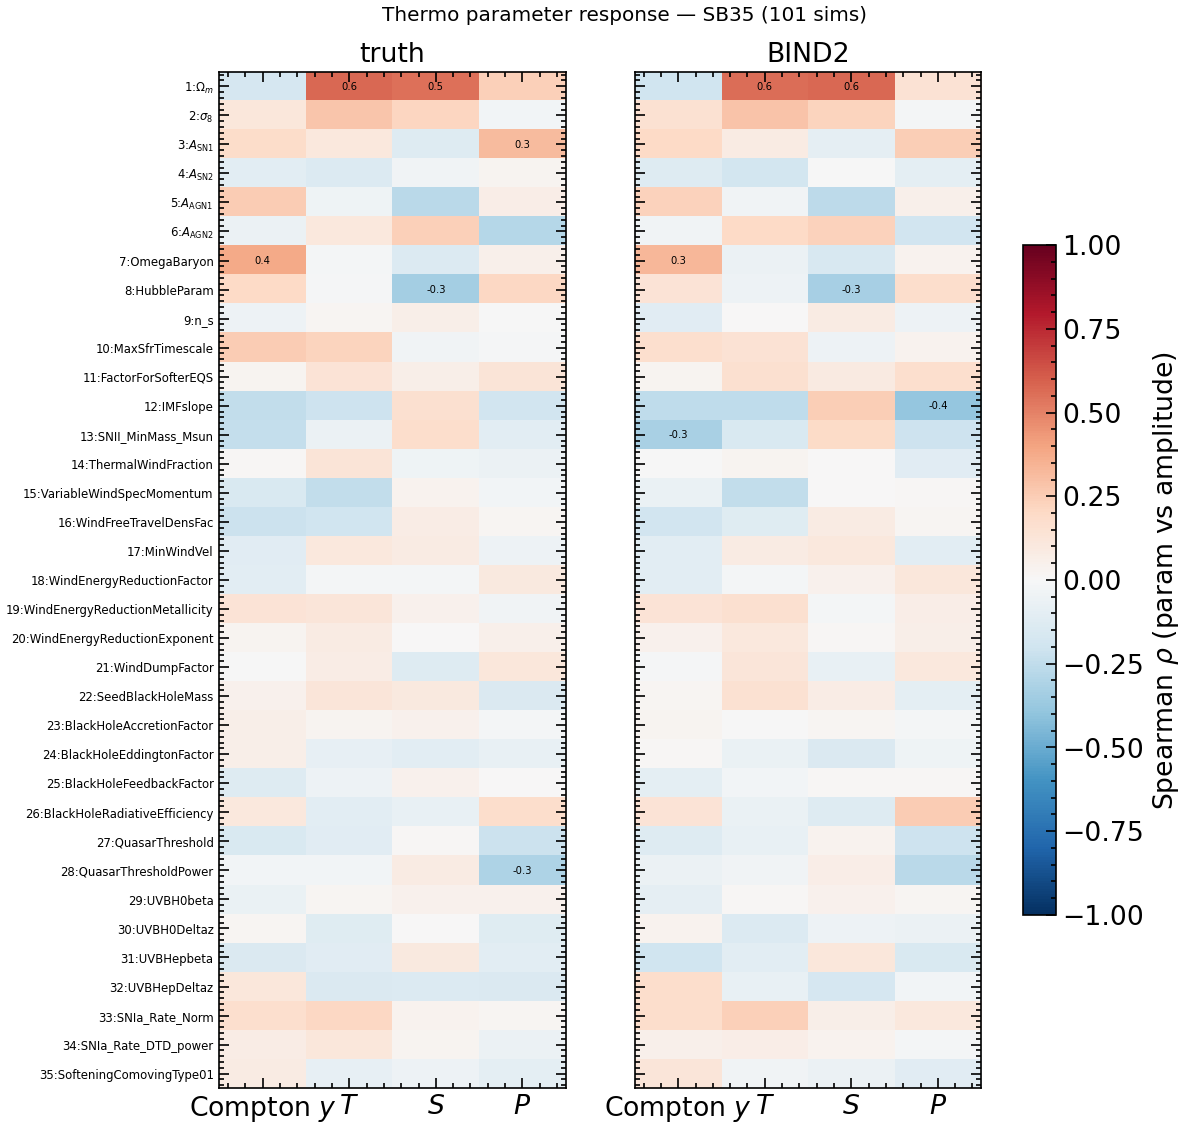

In [11]:
def sim_level_table(tbl, suite='Test'):
    df = tbl[tbl['suite'] == suite].copy()
    for nm in THERMO_NAMES:
        sh = THERMO_SHORT[nm]
        for which in ('truth', 'gen'):
            col = f'{which}_{sh}'
            with np.errstate(divide='ignore', invalid='ignore'):
                df['log_' + col] = np.where(df[col] > 0, np.log10(df[col]), np.nan)
    agg = {f'log_{w}_{THERMO_SHORT[nm]}': 'median'
           for nm in THERMO_NAMES for w in ('truth', 'gen')}
    agg.update({f'p{j}': 'first' for j in range(1, N_PARAMS + 1)})
    return df.groupby('sim_id').agg(agg).reset_index()


def fig_t7_param_response(tbl=None, suite='Test', save=True):
    if tbl is None:
        tbl = halo_tbl
    sl = sim_level_table(tbl, suite)
    params = np.arange(1, N_PARAMS + 1)
    # matrix: (param, field) for truth and gen
    M = {w: np.full((N_PARAMS, N_THERMO), np.nan) for w in ('truth', 'gen')}
    for pi, j in enumerate(params):
        pv = sl[f'p{j}'].to_numpy()
        if np.nanstd(pv) == 0:
            continue
        for ci, nm in enumerate(THERMO_NAMES):
            for w in ('truth', 'gen'):
                yv = sl[f'log_{w}_{THERMO_SHORT[nm]}'].to_numpy()
                m = np.isfinite(pv) & np.isfinite(yv)
                if m.sum() > 5:
                    M[w][pi, ci] = spearmanr(pv[m], yv[m]).correlation

    fig, axes = plt.subplots(1, 2, figsize=(9, 11), sharey=True)
    for k, w in enumerate(['truth', 'gen']):
        ax = axes[k]
        im = ax.imshow(M[w], vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
        ax.set_xticks(range(N_THERMO))
        ax.set_xticklabels([THERMO_LABELS[nm] for nm in THERMO_NAMES])
        ax.set_yticks(range(N_PARAMS))
        ax.set_yticklabels([f'{j}:{PARAM_LABELS[j]}' for j in params], fontsize=7)
        ax.set_title('truth' if w == 'truth' else 'BIND2')
        for pi in range(N_PARAMS):
            for ci in range(N_THERMO):
                if np.isfinite(M[w][pi, ci]) and abs(M[w][pi, ci]) > 0.3:
                    ax.text(ci, pi, f'{M[w][pi, ci]:.1f}', ha='center', va='center',
                            fontsize=6)
    fig.colorbar(im, ax=axes, fraction=0.04, label='Spearman $\\rho$ (param vs amplitude)')
    fig.suptitle(f'Thermo parameter response — {SUITE_DISPLAY[suite]} ({len(sl)} sims)', y=0.93)
    if save:
        save_fig(fig, 'figT7_param_response')
    return fig, M


fig, _param_M = fig_t7_param_response()
plt.show()

## 9. Figure T8 — Butterfly plots (1P field response)

The "butterfly" diagnostic: for each 1P feedback parameter, take the most
massive halo in the high (`_2`) and low (`_n2`) variant and map the
$\log_{10}$(hi/lo) response field. Truth and BIND2 are shown side-by-side per
field — does BIND reproduce *where* and *how strongly* each thermo field
responds to a feedback knob?

  wrote paper_figures_thermo/figT8_butterfly.pdf
  wrote paper_figures_thermo/figT8_butterfly.png


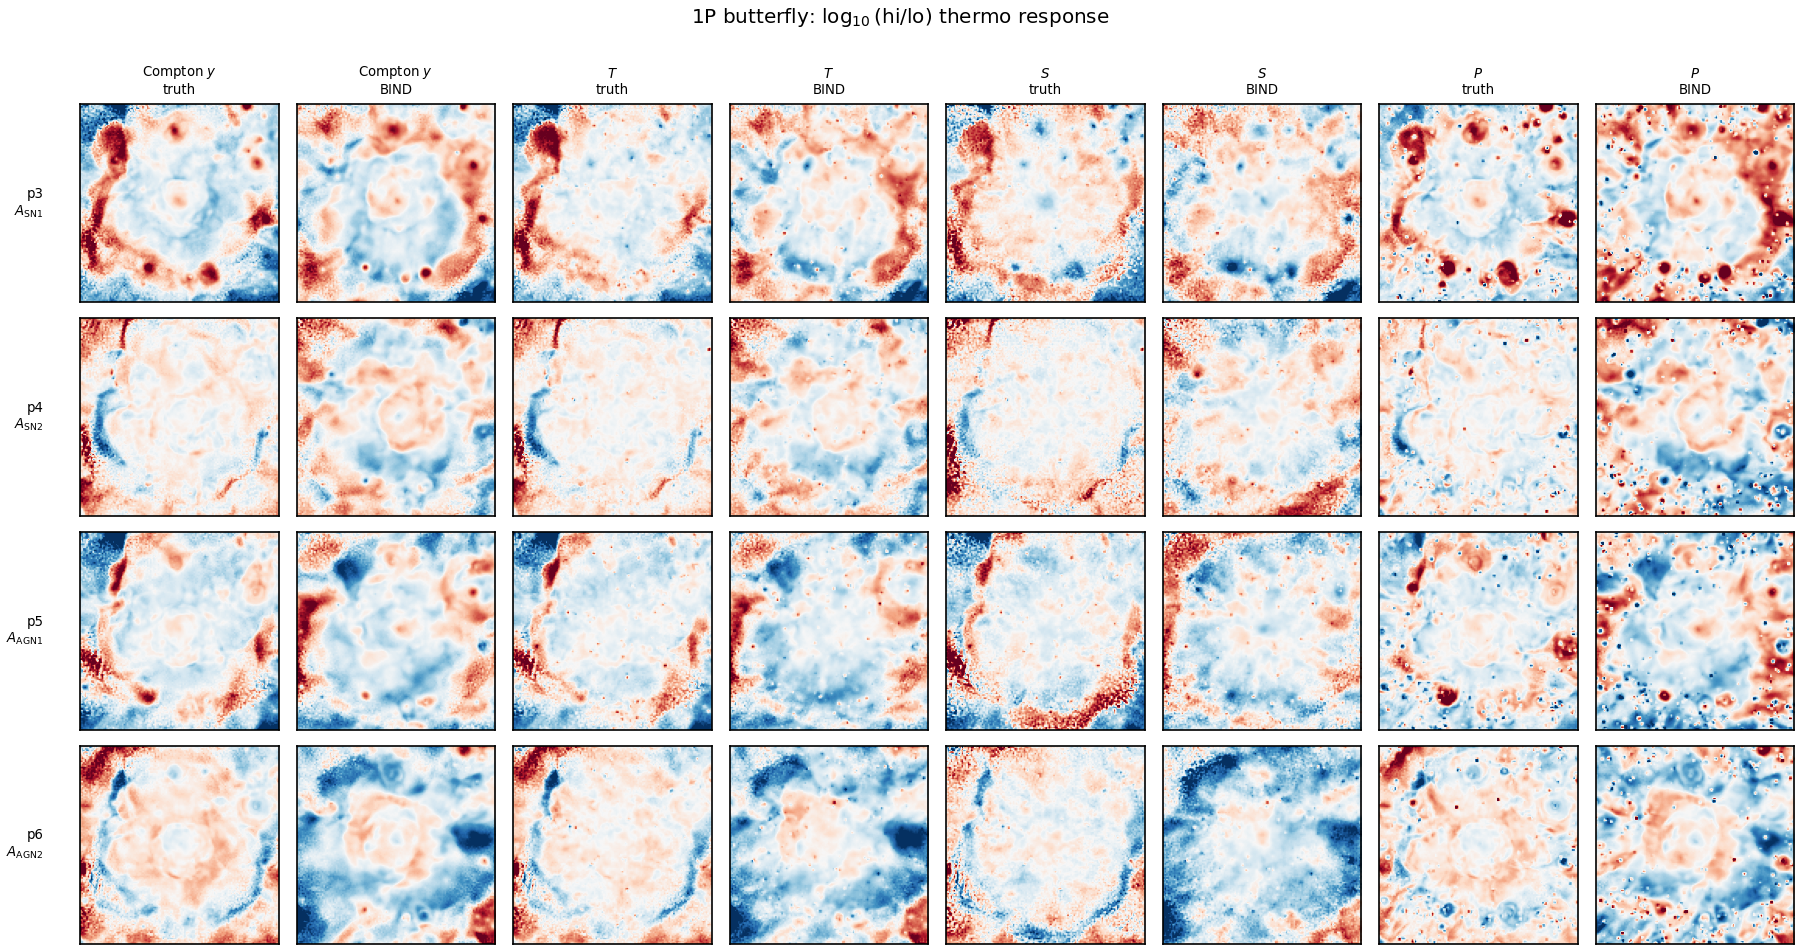

In [12]:
def find_1p_pair(param_idx, variant_hi='2', variant_lo='n2'):
    sid_hi = f'1P_p{param_idx}_{variant_hi}'
    sid_lo = f'1P_p{param_idx}_{variant_lo}'
    hi = oneP_sims[oneP_sims['sim_id'] == sid_hi]
    lo = oneP_sims[oneP_sims['sim_id'] == sid_lo]
    if len(hi) == 0 or len(lo) == 0:
        return None, None
    return hi.iloc[0].to_dict(), lo.iloc[0].to_dict()


def _most_massive_thermo(rec):
    p = load_thermo_patches(rec)
    i = int(np.argmax(p['masses']))
    return p['truth_th'][i], p['gen_th'][i]      # (4,H,W) each


def fig_t8_butterfly(param_indices=None, save=True):
    if param_indices is None:
        param_indices = [j for j in FEEDBACK_PARAMS if find_1p_pair(j)[0] is not None]
    # per-field adaptive floor from positive pixels
    fields = {}
    for j in param_indices:
        hi, lo = find_1p_pair(j)
        t_hi, g_hi = _most_massive_thermo(hi)
        t_lo, g_lo = _most_massive_thermo(lo)
        fields[j] = dict(t_hi=t_hi, t_lo=t_lo, g_hi=g_hi, g_lo=g_lo)
    floors = []
    for c in range(N_THERMO):
        parts = []
        for fd in fields.values():
            for key in ('t_hi', 't_lo', 'g_hi', 'g_lo'):
                v = fd[key][c].ravel(); parts.append(v[v > 0])
        floors.append(max(np.percentile(np.concatenate(parts), 50) * 1e-3, 1e-30)
                      if parts else 1e-30)
    eps = np.array(floors).reshape(N_THERMO, 1, 1)
    lr = {j: dict(t=np.log10((fd['t_hi'] + eps) / (fd['t_lo'] + eps)),
                  g=np.log10((fd['g_hi'] + eps) / (fd['g_lo'] + eps)))
          for j, fd in fields.items()}
    vmax = {}
    for c in range(N_THERMO):
        allabs = np.concatenate([np.abs(lr[j]['t'][c]).ravel() for j in lr] +
                                [np.abs(lr[j]['g'][c]).ravel() for j in lr])
        vmax[c] = max(float(np.quantile(allabs, 0.99)), 0.05)

    n_rows = len(param_indices)
    n_cols = N_THERMO * 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.9 * n_cols, 2.0 * n_rows),
                             squeeze=False)
    for ri, j in enumerate(param_indices):
        for c, nm in enumerate(THERMO_NAMES):
            norm = Normalize(-vmax[c], vmax[c])
            for k, side in enumerate(('t', 'g')):
                ax = axes[ri][2 * c + k]
                im = ax.imshow(lr[j][side][c], origin='lower', cmap='RdBu_r', norm=norm)
                ax.set_xticks([]); ax.set_yticks([])
                if ri == 0:
                    ax.set_title(f'{THERMO_LABELS[nm]}\n{"truth" if side == "t" else "BIND"}',
                                 fontsize=8)
            if c == 0:
                axes[ri][0].set_ylabel(f'p{j}\n{PARAM_LABELS[j]}', fontsize=8,
                                       rotation=0, labelpad=22, va='center', ha='right')
    fig.suptitle(r'1P butterfly: $\log_{10}(\mathrm{hi}/\mathrm{lo})$ thermo response', y=1.0)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figT8_butterfly')
    return fig


fig = fig_t8_butterfly()
plt.show()

### Figure T8b — Butterfly response amplitude vs parameter

Summarises the butterfly maps: for every valid 1P pair, the standard deviation
of the $\log_{10}$(hi/lo) response field (a scalar "how much does this field
respond to this parameter"), truth vs BIND. Tells us which feedback knobs each
thermo field is most sensitive to, and whether BIND captures that ranking.

  wrote paper_figures_thermo/figT8b_response_amplitude.pdf
  wrote paper_figures_thermo/figT8b_response_amplitude.png


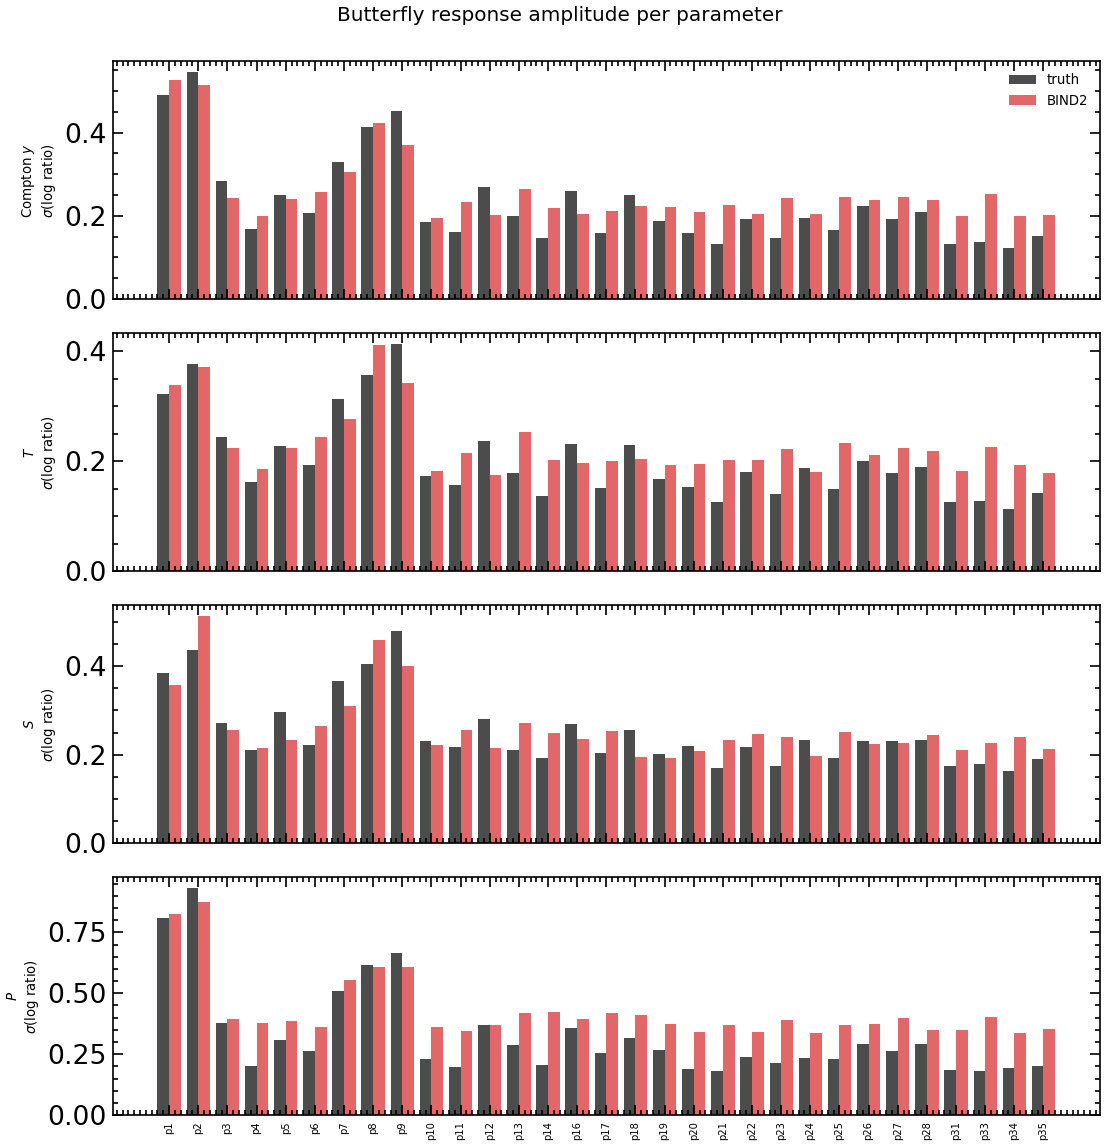

In [13]:
def fig_t8b_response_amplitude(save=True):
    valid = [j for j in range(1, N_PARAMS + 1) if find_1p_pair(j)[0] is not None]
    amp = {nm: {'t': [], 'g': []} for nm in THERMO_NAMES}
    for j in valid:
        hi, lo = find_1p_pair(j)
        t_hi, g_hi = _most_massive_thermo(hi)
        t_lo, g_lo = _most_massive_thermo(lo)
        for c, nm in enumerate(THERMO_NAMES):
            eps = max(np.percentile(t_hi[c][t_hi[c] > 0], 50) * 1e-3, 1e-30) \
                if (t_hi[c] > 0).any() else 1e-30
            tlr = np.log10((t_hi[c] + eps) / (t_lo[c] + eps))
            glr = np.log10((g_hi[c] + eps) / (g_lo[c] + eps))
            amp[nm]['t'].append(np.std(tlr)); amp[nm]['g'].append(np.std(glr))
    x = np.arange(len(valid))
    fig, axes = plt.subplots(N_THERMO, 1, figsize=(max(8, 0.3 * len(valid)), 2.4 * N_THERMO),
                             sharex=True)
    for c, nm in enumerate(THERMO_NAMES):
        ax = axes[c]
        ax.bar(x - 0.2, amp[nm]['t'], width=0.4, color='k', alpha=0.7, label='truth')
        ax.bar(x + 0.2, amp[nm]['g'], width=0.4, color='tab:red', alpha=0.7, label='BIND2')
        ax.set_ylabel(f'{THERMO_LABELS[nm]}\n$\\sigma$(log ratio)', fontsize=8)
        if c == 0:
            ax.legend(fontsize=8)
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels([f'p{j}' for j in valid], rotation=90, fontsize=6)
    fig.suptitle('Butterfly response amplitude per parameter', y=1.0)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figT8b_response_amplitude')
    return fig


fig = fig_t8b_response_amplitude()
plt.show()

## 10. Numeric scorecard

Aggregates the per-sim `thermo_metrics` (dex bias / scatter) stored in each
`summary.json` across suites, alongside the scaling-relation slope recovery.

In [14]:
def thermo_scorecard(sims_df=None):
    if sims_df is None:
        sims_df = sims
    rows = []
    for rec in sims_df.to_dict('records'):
        s = load_summary(rec)
        tm = s.get('thermo_metrics')
        if not tm:
            continue
        for nm in THERMO_NAMES:
            d = tm.get(nm, {})
            if d.get('log10_bias_median') is None:
                continue
            rows.append({'suite': rec['suite'], 'field': nm,
                         'bias': d['log10_bias_median'], 'scatter': d['log10_scatter_std']})
    df = pd.DataFrame(rows)
    print('=' * 64)
    print('Per-pixel dex bias / scatter (median over sims), by suite & field')
    print('=' * 64)
    summ = df.groupby(['suite', 'field']).agg(
        bias_med=('bias', 'median'), scatter_med=('scatter', 'median'),
        n_sims=('bias', 'size')).reset_index()
    for suite in df['suite'].unique():
        print(f'\n[{SUITE_DISPLAY.get(suite, suite)}]')
        sub = summ[summ['suite'] == suite]
        for _, r in sub.iterrows():
            print(f'  {r["field"]:12s}  bias={r["bias_med"]:+.3f} dex  '
                  f'scatter={r["scatter_med"]:.3f} dex  (n={int(r["n_sims"])})')
    return summ


scorecard = thermo_scorecard()

Per-pixel dex bias / scatter (median over sims), by suite & field

[CV]
  compton_y     bias=-0.039 dex  scatter=0.292 dex  (n=27)
  entropy       bias=-0.032 dex  scatter=0.273 dex  (n=27)
  pressure      bias=-0.015 dex  scatter=0.476 dex  (n=27)
  temperature   bias=-0.028 dex  scatter=0.266 dex  (n=27)

[1P]
  compton_y     bias=-0.029 dex  scatter=0.290 dex  (n=139)
  entropy       bias=-0.025 dex  scatter=0.267 dex  (n=139)
  pressure      bias=+0.004 dex  scatter=0.474 dex  (n=139)
  temperature   bias=-0.018 dex  scatter=0.264 dex  (n=139)

[SB35]
  compton_y     bias=+0.006 dex  scatter=0.290 dex  (n=101)
  entropy       bias=-0.003 dex  scatter=0.281 dex  (n=101)
  pressure      bias=+0.013 dex  scatter=0.479 dex  (n=101)
  temperature   bias=+0.005 dex  scatter=0.270 dex  (n=101)


## 11. Figure T9 — Y–M residuals vs projected baryon fraction

Halos scatter off the mean Y–M relation for two reasons: more/hotter gas (higher
$T$ at fixed mass) or more gas (higher $f_{\rm gas}$). Here we ask the simpler
structural question: **do halos that sit above the self-similar Y–M relation also
have anomalously high projected gas fractions?**

Method: fit an OLS power-law $\log Y = a\log M + b$ to the sample; similarly fit
$\log f_{\rm gas}^{\rm proj} = c\log M + d$ (where $f_{\rm gas}^{\rm proj}=
M_{\rm gas,ap}/M_{200}$ is the 2-D/3-D mixed proxy available from the maps);
compute residuals $\Delta\log Y$ and $\Delta\log f_{\rm gas}$; correlate them.
A strong Spearman $\rho$ would say "yes — the scatter is gas-fraction driven".
A weak $\rho$ would say the scatter is primarily thermodynamic (T/S at fixed
gas mass). The right column shows the full $f_{\rm gas}$–Y plane coloured by
mass to check whether mass is a hidden driver.

  wrote paper_figures_thermo/figT9_ym_vs_fb.pdf
  wrote paper_figures_thermo/figT9_ym_vs_fb.png


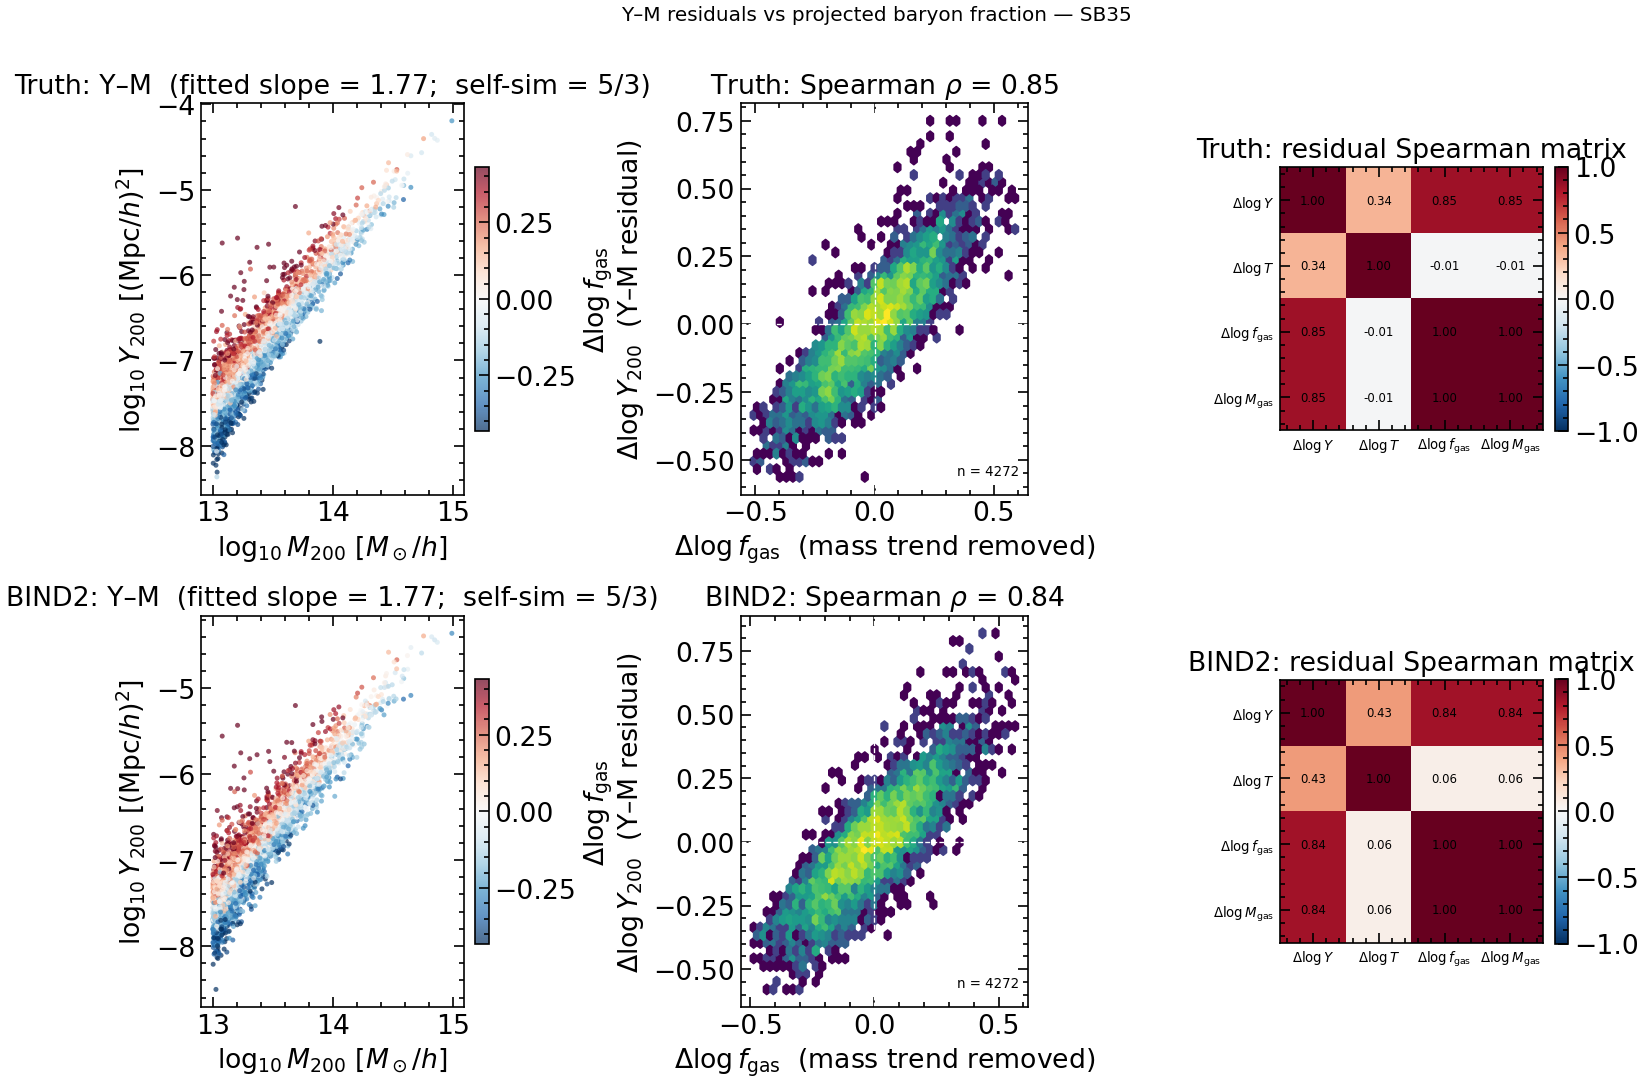

In [ ]:
def _ols_residuals(x, y):
    """OLS fit y ~ a·x+b; return (residuals array, slope). NaN-safe."""
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 4:
        return np.full_like(y, np.nan), np.nan
    sl, inter = np.polyfit(x[m], y[m], 1)
    return y - (sl * x + inter), sl


def build_residual_frame(tbl, suite='Test'):
    """Add log-space residuals ΔY (from Y–M fit), Δfb, ΔT, ΔS, ΔP, ΔMg."""
    df   = tbl[tbl['suite'] == suite].copy()
    logM = df['logM'].to_numpy()
    for which in ('truth', 'gen'):
        Mg = df[f'{which}_Mgas'].to_numpy()
        logMg = np.where(Mg > 0, np.log10(Mg), np.nan)
        logfb = np.where(Mg > 0, logMg - logM, np.nan)   # log(Mgas/M200) proxy
        dMg, _ = _ols_residuals(logM, logMg)
        dfb, _ = _ols_residuals(logM, logfb)
        df[f'{which}_logfb'] = logfb
        df[f'{which}_dMg']   = dMg
        df[f'{which}_dfb']   = dfb
        # all four thermo fields
        for nm in THERMO_NAMES:
            sh  = THERMO_SHORT[nm]
            v   = df[f'{which}_{sh}'].to_numpy()
            logv = np.where(v > 0, np.log10(v), np.nan)
            dv, sl = _ols_residuals(logM, logv)
            df[f'{which}_log{sh}'] = logv
            df[f'{which}_d{sh}']   = dv
            if nm == 'compton_y':
                df[f'slope_YM_{which}'] = sl
    return df


def _resid_corrmat(df, which):
    """Spearman corr matrix: ΔY, ΔT, ΔS, ΔP, Δfgas, ΔMgas (all mass-detrended)."""
    keys   = (['d' + THERMO_SHORT[nm] for nm in THERMO_NAMES]
              + ['dfb', 'dMg'])
    labels = ([r'$\Delta\log Y$', r'$\Delta\log T$',
               r'$\Delta\log S$', r'$\Delta\log P$']
              + [r'$\Delta\log f_{\rm gas}$', r'$\Delta\log M_{\rm gas}$'])
    cols, labs = [], []
    for k, lab in zip(keys, labels):
        col = f'{which}_{k}'
        if col in df.columns:
            cols.append(col); labs.append(lab)
    n = len(cols)
    C = np.full((n, n), np.nan)
    data = [df[c].to_numpy() for c in cols]
    for a in range(n):
        for b in range(n):
            m = np.isfinite(data[a]) & np.isfinite(data[b])
            if m.sum() > 5:
                C[a, b] = spearmanr(data[a][m], data[b][m]).correlation
    return C, labs


def fig_t9_ym_vs_fb(tbl=None, suite='Test', save=True):
    if tbl is None:
        tbl = halo_tbl
    df   = build_residual_frame(tbl, suite)
    logM = df['logM'].to_numpy()

    vmax_dfb = np.nanpercentile(np.abs(
        np.concatenate([df['truth_dfb'].to_numpy(), df['gen_dfb'].to_numpy()])), 97)

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    fig.suptitle(f'Y–M residuals vs projected baryon fraction — {SUITE_DISPLAY[suite]}', y=1.01)

    for ri, which in enumerate(('truth', 'gen')):
        label = 'Truth' if which == 'truth' else 'BIND2'
        logY  = df[f'{which}_logY'].to_numpy()
        logfb = df[f'{which}_logfb'].to_numpy()
        dY    = df[f'{which}_dY'].to_numpy()
        dfb   = df[f'{which}_dfb'].to_numpy()
        sl    = float(df[f'slope_YM_{which}'].iloc[0])

        # ── Col 0: Y–M coloured by Δfb ────────────────────────────────────
        ax = axes[ri, 0]
        m  = np.isfinite(logY) & np.isfinite(dfb)
        sc = ax.scatter(logM[m], logY[m], c=dfb[m], s=9, alpha=0.7,
                        cmap='RdBu_r', vmin=-vmax_dfb, vmax=vmax_dfb, linewidths=0)
        ax.set_xlabel(r'$\log_{10} M_{200}\ [M_\odot/h]$')
        ax.set_ylabel(r'$\log_{10} Y_{200}\ [(\mathrm{Mpc}/h)^2]$')
        ax.set_title(f'{label}: Y–M  (fitted slope = {sl:.2f};  self-sim = 5/3)')
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04,
                     label=r'$\Delta\log f_{\rm gas}$')

        # ── Col 1: δY vs δfb hexbin ──────────────────────────────────────
        ax  = axes[ri, 1]
        m2  = np.isfinite(dY) & np.isfinite(dfb)
        r_s = spearmanr(dfb[m2], dY[m2]).correlation
        lo_x, hi_x = np.nanpercentile(dfb[m2], [0.5, 99.5])
        lo_y, hi_y = np.nanpercentile(dY[m2],  [0.5, 99.5])
        ax.hexbin(dfb[m2], dY[m2], gridsize=40, bins='log', cmap='viridis',
                  extent=(lo_x, hi_x, lo_y, hi_y))
        ax.axhline(0, color='w', ls='--', lw=0.8)
        ax.axvline(0, color='w', ls='--', lw=0.8)
        ax.set_xlabel(r'$\Delta\log f_{\rm gas}$  (mass trend removed)')
        ax.set_ylabel(r'$\Delta\log Y_{200}$  (Y–M residual)')
        ax.set_title(f'{label}: Spearman $\\rho$ = {r_s:.2f}')
        ax.text(0.97, 0.05, f'n = {m2.sum()}', transform=ax.transAxes,
                ha='right', fontsize=8)

        # ── Col 2: residual Spearman correlation matrix ───────────────────
        ax    = axes[ri, 2]
        C, labs = _resid_corrmat(df, which)
        im    = ax.imshow(C, vmin=-1, vmax=1, cmap='RdBu_r')
        ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, fontsize=8)
        ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=8)
        for a in range(len(labs)):
            for b in range(len(labs)):
                if np.isfinite(C[a, b]):
                    ax.text(b, a, f'{C[a, b]:.2f}', ha='center', va='center',
                            fontsize=7, color='k')
        ax.set_title(f'{label}: residual Spearman matrix')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    if save:
        save_fig(fig, 'figT9_ym_vs_fb')
    return fig


fig = fig_t9_ym_vs_fb()
plt.show()

## 12. Figure T10 — Y radial profiles as a function of parameters

**T10a — 1P hi/lo profiles:** For each feedback parameter (A_SN1, A_SN2, A_AGN1,
A_AGN2), take the extreme hi/lo 1P variants, select halos above a mass cut, and
compute the mean azimuthal Compton-$y$ profile in $r/R_{200}$ units. The *top
row* shows absolute profiles (log scale); the *bottom row* shows the
$\log_{10}$(hi/lo) response — analogous to the butterfly maps but radially
resolved. This mirrors analyses in e.g. Hadzhiyska et al. (CARPoolGP), which
show that AGN feedback strongly evacuates gas from cluster cores, flattening the
central $y$ profile while enhancing the outskirts.

**T10b — SB35 continuous variation:** For a random subsample of SB35 (Test) sims,
compute the mean $y$ profile over massive halos and colour-code by $A_{\rm AGN1}$
and $A_{\rm AGN2}$ value. Solid lines = truth; dashed = BIND2. This shows the
*continuous* parameter sensitivity across the SB35 prior, and whether BIND2
correctly learns the direction and magnitude of the feedback-induced profile
deformation.

  wrote paper_figures_thermo/figT10a_y_profiles_1p.pdf
  wrote paper_figures_thermo/figT10a_y_profiles_1p.png


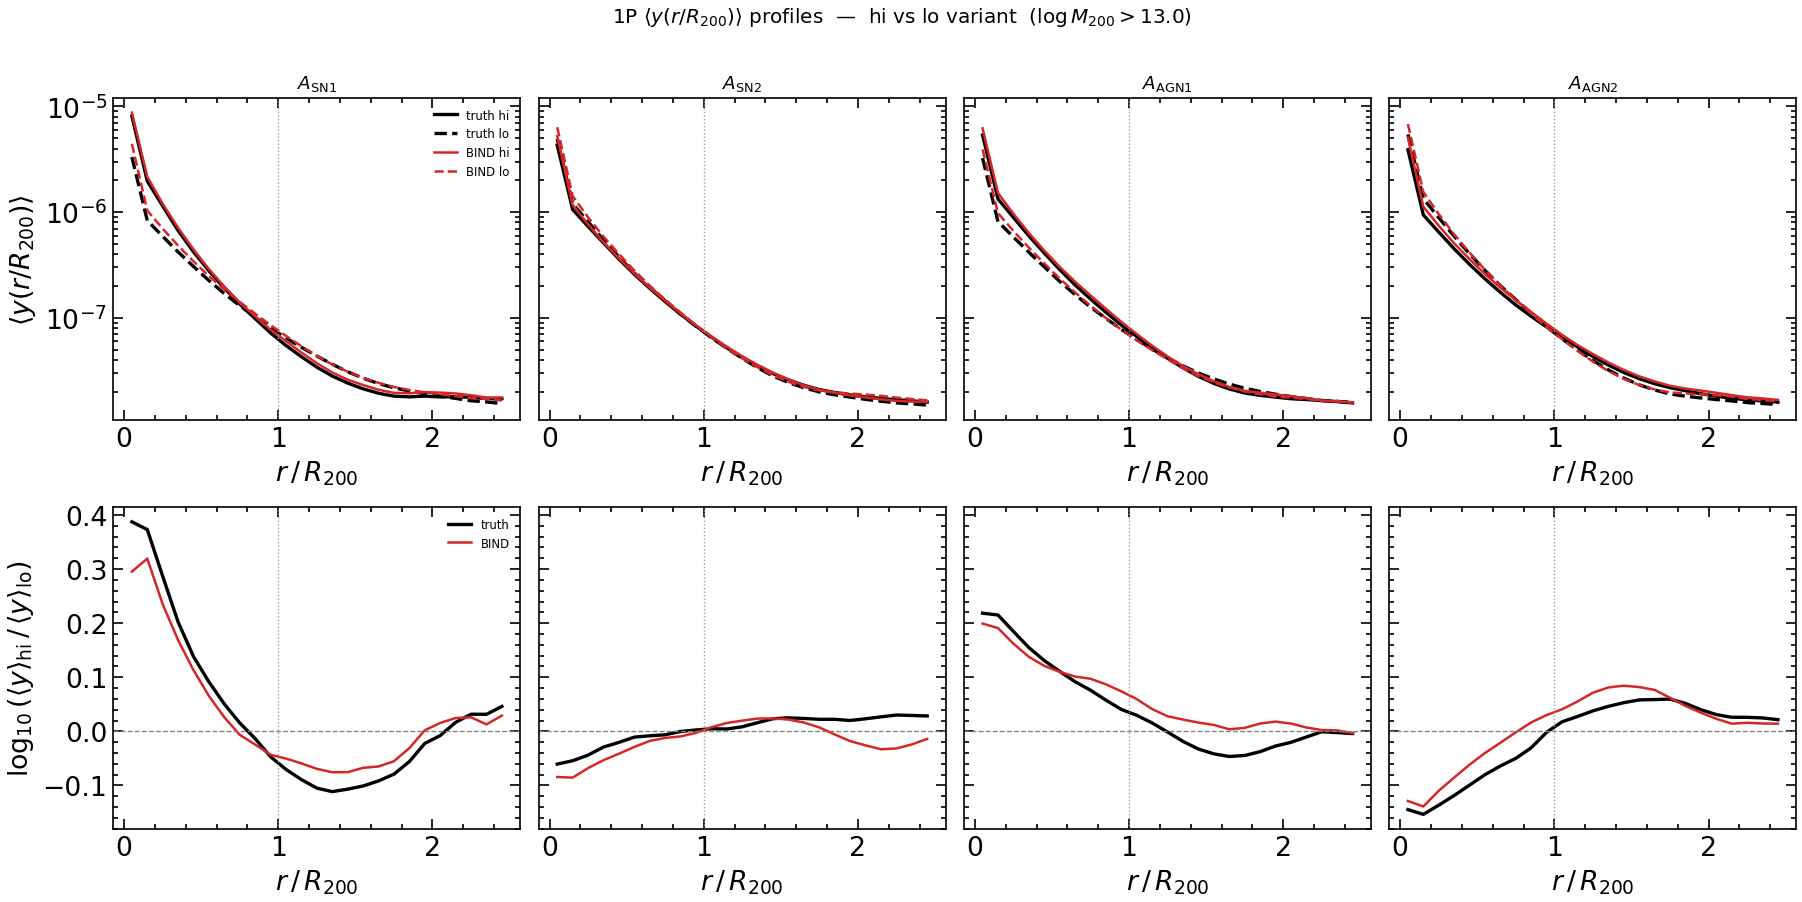

In [16]:
# ── radial profile helpers (r/R200 bins) ────────────────────────────────────
R_BINS_PROF = np.linspace(0, 2.5, 26)
R_BC_PROF   = 0.5 * (R_BINS_PROF[1:] + R_BINS_PROF[:-1])


def _y_profile_halo(field_2d, r200_pix, channel=0):
    """Vectorised azimuthal mean in r/R200 bins (positive-pixel mean)."""
    r_f  = (_RR / max(r200_pix, 1.0)).ravel()
    v_f  = field_2d.ravel()
    bidx = np.digitize(r_f, R_BINS_PROF) - 1   # 0-indexed
    valid = (bidx >= 0) & (bidx < len(R_BC_PROF)) & (v_f > 0)
    cnt  = np.bincount(bidx[valid], minlength=len(R_BC_PROF))
    sums = np.bincount(bidx[valid], weights=v_f[valid], minlength=len(R_BC_PROF))
    prof = np.full(len(R_BC_PROF), np.nan)
    m    = cnt >= 2
    prof[m] = sums[m] / cnt[m]
    return prof


def sim_mean_y_profile(rec, channel=0, logM_min=13.0):
    """Mean truth & BIND y profile (channel=0) over halos above logM_min."""
    try:
        p = load_thermo_patches(rec)
    except Exception:
        return None, None
    sel = np.where(np.log10(p['masses']) >= logM_min)[0]
    if len(sel) == 0:
        return None, None
    t_profs, g_profs = [], []
    for i in sel:
        r200 = p['radii'][i] / PIX_KPC
        t_profs.append(_y_profile_halo(p['truth_th'][i, channel], r200))
        g_profs.append(_y_profile_halo(p['gen_th'][i, channel],   r200))
    return np.nanmean(t_profs, axis=0), np.nanmean(g_profs, axis=0)


# ── T10a: 1P hi/lo profiles ──────────────────────────────────────────────────
def fig_t10a_profiles_1p(logM_min=13.0, save=True):
    valid_fp = [j for j in FEEDBACK_PARAMS if find_1p_pair(j)[0] is not None]
    if not valid_fp:
        print('[skip] no valid 1P feedback pairs found'); return None

    fig, axes = plt.subplots(2, len(valid_fp),
                             figsize=(3.8 * len(valid_fp), 7.5),
                             sharey='row')
    if len(valid_fp) == 1:
        axes = axes[:, np.newaxis]
    fig.suptitle(r'1P $\langle y(r/R_{200}) \rangle$ profiles  —  hi vs lo variant'
                 f'  (log$\\,M_{{200}} > {logM_min}$)', y=1.01)

    for pj, j in enumerate(valid_fp):
        hi_rec, lo_rec = find_1p_pair(j)
        t_hi, g_hi = sim_mean_y_profile(hi_rec, logM_min=logM_min)
        t_lo, g_lo = sim_mean_y_profile(lo_rec, logM_min=logM_min)
        if t_hi is None or t_lo is None:
            continue

        # row 0: absolute profiles (log scale)
        ax = axes[0, pj]
        ax.semilogy(R_BC_PROF, t_hi, 'k-',   lw=2,   label='truth hi')
        ax.semilogy(R_BC_PROF, t_lo, 'k--',  lw=2,   label='truth lo')
        ax.semilogy(R_BC_PROF, g_hi, '-',    lw=1.5, color='tab:red', label='BIND hi')
        ax.semilogy(R_BC_PROF, g_lo, '--',   lw=1.5, color='tab:red', label='BIND lo')
        ax.axvline(1.0, color='0.6', ls=':', lw=0.8)
        ax.set_title(PARAM_LABELS[j], fontsize=11)
        ax.set_xlabel(r'$r\,/\,R_{200}$')
        if pj == 0:
            ax.set_ylabel(r'$\langle y(r/R_{200}) \rangle$')
            ax.legend(fontsize=7)

        # row 1: log10 response ratio  hi / lo
        ax = axes[1, pj]
        with np.errstate(divide='ignore', invalid='ignore'):
            tr = np.log10(np.where((t_hi > 0) & (t_lo > 0), t_hi / t_lo, np.nan))
            gr = np.log10(np.where((g_hi > 0) & (g_lo > 0), g_hi / g_lo, np.nan))
        ax.plot(R_BC_PROF, tr, 'k-',  lw=2,   label='truth')
        ax.plot(R_BC_PROF, gr, '-',   lw=1.5, color='tab:red', label='BIND')
        ax.axhline(0, color='0.5', ls='--', lw=0.8)
        ax.axvline(1.0, color='0.6', ls=':', lw=0.8)
        ax.set_xlabel(r'$r\,/\,R_{200}$')
        if pj == 0:
            ax.set_ylabel(r'$\log_{10}(\langle y\rangle_{\rm hi}\,/\,\langle y\rangle_{\rm lo})$')
            ax.legend(fontsize=7)

    fig.tight_layout()
    if save:
        save_fig(fig, 'figT10a_y_profiles_1p')
    return fig


fig_a = fig_t10a_profiles_1p()
plt.show()

In [ ]:
# ── T10b: SB35 profiles coloured by AGN feedback ─────────────────────────────
def fig_t10b_profiles_sb35(tbl=None, logM_min=13.0, max_sims=80, save=True):
    """
    For a random subsample of SB35 (Test) sims, compute the mean Y profile over
    massive halos and colour-code by A_AGN1 (p5) and A_AGN2 (p6).
    Solid = truth, dashed = BIND2.
    """
    if tbl is None:
        tbl = halo_tbl
    recs = test_sims.sample(min(max_sims, len(test_sims)),
                            random_state=42).to_dict('records')

    profiles_t, profiles_g, pvals_agn1, pvals_agn2 = [], [], [], []
    for rec in recs:
        tp, gp = sim_mean_y_profile(rec, logM_min=logM_min)
        if tp is None or not np.any(np.isfinite(tp)):
            continue
        sub = tbl[(tbl['suite'] == 'Test') & (tbl['sim_id'] == rec['sim_id'])]
        if len(sub) == 0:
            continue
        profiles_t.append(tp)
        profiles_g.append(gp)
        pvals_agn1.append(float(sub.iloc[0]['p5']))   # A_AGN1
        pvals_agn2.append(float(sub.iloc[0]['p6']))   # A_AGN2

    print(f'  Loaded {len(profiles_t)} Test sim profiles  '
          f'(logM_min={logM_min}, max_sims={max_sims})')

    if not profiles_t:
        print('[skip] no profiles loaded'); return None

    # shared y limits from truth profiles
    all_vals = np.concatenate([p[np.isfinite(p) & (p > 0)] for p in profiles_t])
    y_lo = np.percentile(all_vals, 1) * 0.5
    y_hi = np.percentile(all_vals, 99) * 2.0

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5),
                             sharey=True, sharex=True)
    fig.suptitle(r'SB35 mean $\langle y(r/R_{200}) \rangle$ profiles  —  '
                 r'coloured by AGN feedback'
                 f'\n(log$\\,M_{{200}} > {logM_min}$,  {len(profiles_t)} sims)',
                 y=1.02)

    for col, (pvals, plabel, param_j) in enumerate([
            (pvals_agn1, PARAM_LABELS[5], 5),
            (pvals_agn2, PARAM_LABELS[6], 6)]):
        pv    = np.array(pvals)
        pnorm = (pv - pv.min()) / (pv.max() - pv.min() + 1e-12)
        cmap  = plt.cm.plasma

        for row, (profs, side) in enumerate([(profiles_t, 'Truth'),
                                             (profiles_g, 'BIND2')]):
            ax = axes[row, col]
            for k, prof in enumerate(profs):
                c = cmap(pnorm[k])
                ax.semilogy(R_BC_PROF, prof, '-', color=c, alpha=0.55, lw=1.1)
            ax.axvline(1.0, color='0.5', ls=':', lw=0.8)
            ax.set_ylim(y_lo, y_hi)
            ax.set_title(f'{side} — colour = {plabel}', fontsize=10)
            if col == 0:
                ax.set_ylabel(r'$\langle y(r/R_{200}) \rangle$')
            if row == 1:
                ax.set_xlabel(r'$r\,/\,R_{200}$')

            sm = plt.cm.ScalarMappable(cmap=cmap,
                                       norm=Normalize(pv.min(), pv.max()))
            sm.set_array([])
            fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label=plabel)

    # overlay median of lowest / highest 20% for truth panels
    for col, pvals in enumerate([pvals_agn1, pvals_agn2]):
        pv = np.array(pvals)
        lo20 = np.where(pv <= np.percentile(pv, 20))[0]
        hi20 = np.where(pv >= np.percentile(pv, 80))[0]
        ax = axes[0, col]
        if len(lo20):
            med_lo = np.nanmedian([profiles_t[k] for k in lo20], axis=0)
            ax.semilogy(R_BC_PROF, med_lo, 'w-', lw=2.5, alpha=0.9, label='lo-20% median')
        if len(hi20):
            med_hi = np.nanmedian([profiles_t[k] for k in hi20], axis=0)
            ax.semilogy(R_BC_PROF, med_hi, 'w--', lw=2.5, alpha=0.9, label='hi-20% median')
        ax.legend(fontsize=7)

    fig.tight_layout()
    if save:
        save_fig(fig, 'figT10b_y_profiles_sb35')
    return fig


fig_b = fig_t10b_profiles_sb35()
plt.show()

/tmp/ipykernel_2559822/739559105.py:34: RuntimeWarning: Mean of empty slice
  return np.nanmean(t_profs, axis=0), np.nanmean(g_profs, axis=0)
